In [1]:
import requests
import pandas as pd
import time
from datetime import datetime

COUNTIES = [
    "alameda", "alpine", "amador", "butte", "calaveras", "colusa",
    "contra-costa", "del-norte", "el-dorado", "fresno", "glenn",
    "humboldt", "imperial", "inyo", "kern", "kings", "lake", "lassen",
    "los-angeles", "madera", "marin", "mariposa", "mendocino", "merced",
    "modoc", "mono", "monterey", "napa", "nevada", "orange", "placer",
    "plumas", "riverside", "sacramento", "san-benito", "san-bernardino",
    "san-diego", "san-francisco", "san-joaquin", "san-luis-obispo",
    "san-mateo", "santa-barbara", "santa-clara", "santa-cruz", "shasta",
    "sierra", "siskiyou", "solano", "sonoma", "stanislaus", "sutter",
    "tehama", "trinity", "tulare", "tuolumne", "ventura", "yolo", "yuba"
]

def clean_votes(x):
    return int(str(x).replace(",", "").strip())

def clean_percent(x):
    return float(str(x).replace("%", "").strip())

def get_county_results(county_slug):
    url = f"https://api.sos.ca.gov/returns/governor/county/{county_slug}"

    res = requests.get(url, params={"_": int(time.time())}, timeout=20)
    res.raise_for_status()
    data = res.json()

    # County endpoints usually return a list with one race object
    if isinstance(data, list):
        race = data[0]
    else:
        race = data

    candidates = race["candidates"]

    df = pd.DataFrame(candidates)

    df["Votes"] = df["Votes"].apply(clean_votes)
    df["Percent"] = df["Percent"].apply(clean_percent)

    df["county_slug"] = county_slug
    df["county"] = county_slug.replace("-", " ").title()
    df["raceTitle"] = race.get("raceTitle")
    df["Reporting"] = race.get("Reporting")
    df["ReportingTime"] = race.get("ReportingTime")
    df["pulled_at"] = datetime.now().isoformat(timespec="seconds")

    return df


all_counties = []

for county in COUNTIES:
    try:
        county_df = get_county_results(county)
        all_counties.append(county_df)
        print(f"Loaded {county}")
    except Exception as e:
        print(f"Failed {county}: {e}")

df_counties = pd.concat(all_counties, ignore_index=True)

df_counties = df_counties.sort_values(
    ["county", "Votes"],
    ascending=[True, False]
).reset_index(drop=True)

df_counties.to_csv("ca_governor_primary_county_level_live.csv", index=False)

df_counties.head(20)

Loaded alameda
Loaded alpine
Loaded amador
Loaded butte
Loaded calaveras
Loaded colusa
Loaded contra-costa
Loaded del-norte
Loaded el-dorado
Loaded fresno
Loaded glenn
Loaded humboldt
Loaded imperial
Loaded inyo
Loaded kern
Loaded kings
Loaded lake
Loaded lassen
Loaded los-angeles
Loaded madera
Loaded marin
Loaded mariposa
Loaded mendocino
Loaded merced
Loaded modoc
Loaded mono
Loaded monterey
Loaded napa
Loaded nevada
Loaded orange
Loaded placer
Loaded plumas
Loaded riverside
Loaded sacramento
Loaded san-benito
Loaded san-bernardino
Loaded san-diego
Loaded san-francisco
Loaded san-joaquin
Loaded san-luis-obispo
Loaded san-mateo
Loaded santa-barbara
Loaded santa-clara
Loaded santa-cruz
Loaded shasta
Loaded sierra
Loaded siskiyou
Loaded solano
Loaded sonoma
Loaded stanislaus
Loaded sutter
Loaded tehama
Loaded trinity
Loaded tulare
Loaded tuolumne
Loaded ventura
Loaded yolo
Loaded yuba


,Name,Party,Votes,Percent,incumbent,county_slug,county,raceTitle,Reporting,ReportingTime,pulled_at
0,Xavier Becerra,Dem,48954,29.7,False,alameda,Alameda,Governor - Alameda County Results,100% (546 of 546) precincts reporting,"June 2, 2026, 11:30 p.m.",2026-06-05T16:24:34
1,Tom Steyer,Dem,45272,27.5,False,alameda,Alameda,Governor - Alameda County Results,100% (546 of 546) precincts reporting,"June 2, 2026, 11:30 p.m.",2026-06-05T16:24:34
2,Steve Hilton,Rep,28108,17.1,False,alameda,Alameda,Governor - Alameda County Results,100% (546 of 546) precincts reporting,"June 2, 2026, 11:30 p.m.",2026-06-05T16:24:34
3,Katie Porter,Dem,12522,7.6,False,alameda,Alameda,Governor - Alameda County Results,100% (546 of 546) precincts reporting,"June 2, 2026, 11:30 p.m.",2026-06-05T16:24:34
4,Matt Mahan,Dem,9417,5.7,False,alameda,Alameda,Governor - Alameda County Results,100% (546 of 546) precincts reporting,"June 2, 2026, 11:30 p.m.",2026-06-05T16:24:34
5,Chad Bianco,Rep,7571,4.6,False,alameda,Alameda,Governor - Alameda County Results,100% (546 of 546) precincts reporting,"June 2, 2026, 11:30 p.m.",2026-06-05T16:24:34
6,Tony K. Thurmond,Dem,1677,1.0,False,alameda,Alameda,Governor - Alameda County Results,100% (546 of 546) precincts reporting,"June 2, 2026, 11:30 p.m.",2026-06-05T16:24:34
7,Ramsey Robinson,P&F,1183,0.7,False,alameda,Alameda,Governor - Alameda County Results,100% (546 of 546) precincts reporting,"June 2, 2026, 11:30 p.m.",2026-06-05T16:24:34
8,Betty T. Yee,Dem,1176,0.7,False,alameda,Alameda,Governor - Alameda County Results,100% (546 of 546) precincts reporting,"June 2, 2026, 11:30 p.m.",2026-06-05T16:24:34
9,Eric Swalwell,Dem,1174,0.7,False,alameda,Alameda,Governor - Alameda County Results,100% (546 of 546) precincts reporting,"June 2, 2026, 11:30 p.m.",2026-06-05T16:24:34


In [2]:
import pandas as pd
import numpy as np

STEVE = "Steve Hilton"
BECERRA = "Xavier Becerra"
STEYER = "Tom Steyer"

def prepare_county_df(df):
    df = df.copy()

    # Clean votes just in case
    df["Votes"] = (
        df["Votes"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    # Make sure county exists
    if "county" not in df.columns:
        if "county_slug" in df.columns:
            df["county"] = df["county_slug"].str.replace("-", " ").str.title()
        else:
            raise ValueError("df needs either a county or county_slug column.")

    return df


def adjust_missing_shares(shares, scenario, rng, cap=0.05):
    """
    shares = Series of candidate vote shares in one county.
    cap=0.05 means max 5 percentage points.
    """

    shares = shares.copy()

    # Make sure the important candidates exist
    for name in [STEVE, BECERRA, STEYER]:
        if name not in shares.index:
            shares.loc[name] = 0.0

    if scenario == "same":
        return shares / shares.sum()

    swing = rng.uniform(0, cap)

    if scenario == "steve_down":
        # Steve loses up to 5 percentage points.
        actual_swing = min(swing, shares[STEVE])

        shares[STEVE] -= actual_swing
        shares[BECERRA] += actual_swing

    elif scenario == "steve_up":
        # Steve gains up to 5 percentage points.
        # He takes half from Becerra and half from Steyer.
        take_from_becerra = min(swing / 2, shares[BECERRA])
        take_from_steyer = min(swing / 2, shares[STEYER])

        actual_swing = take_from_becerra + take_from_steyer

        shares[BECERRA] -= take_from_becerra
        shares[STEYER] -= take_from_steyer
        shares[STEVE] += actual_swing

    else:
        raise ValueError("scenario must be: 'same', 'steve_down', or 'steve_up'")

    # Normalize to avoid tiny floating point issues
    shares = shares.clip(lower=0)
    shares = shares / shares.sum()

    return shares


def project_final_votes_once(
    df_counties,
    missing_frac=0.50,
    scenario="same",
    cap=0.05,
    seed=None
):
    """
    missing_frac = fraction of FINAL votes that are still missing.

    Example:
    missing_frac=0.50 means current votes are only 50% of final votes.
    So if a county currently has 500k votes, projected final is 1M.
    """

    rng = np.random.default_rng(seed)
    df = prepare_county_df(df_counties)

    projected_rows = []

    for county, g in df.groupby("county"):
        current_total = g["Votes"].sum()

        if current_total == 0:
            continue

        final_total = current_total / (1 - missing_frac)
        missing_votes = final_total - current_total

        current_shares = g.set_index("Name")["Votes"] / current_total

        missing_shares = adjust_missing_shares(
            current_shares,
            scenario=scenario,
            rng=rng,
            cap=cap
        )

        # Current votes stay fixed
        projected = g.set_index("Name")["Votes"].copy()

        # Add missing votes based on adjusted missing-vote shares
        for candidate, share in missing_shares.items():
            if candidate not in projected.index:
                projected.loc[candidate] = 0.0

            projected.loc[candidate] += missing_votes * share

        county_result = projected.reset_index()
        county_result.columns = ["Name", "ProjectedVotes"]
        county_result["county"] = county
        county_result["scenario"] = scenario

        projected_rows.append(county_result)

    projected_df = pd.concat(projected_rows, ignore_index=True)

    statewide = (
        projected_df
        .groupby("Name", as_index=False)["ProjectedVotes"]
        .sum()
        .sort_values("ProjectedVotes", ascending=False)
        .reset_index(drop=True)
    )

    statewide["ProjectedPercent"] = (
        statewide["ProjectedVotes"] / statewide["ProjectedVotes"].sum() * 100
    )

    winner = statewide.iloc[0]["Name"]

    return statewide, projected_df, winner

In [3]:
statewide_same, county_same, winner_same = project_final_votes_once(
    df_counties,
    missing_frac=0.50,
    scenario="same",
    seed=42
)

print("Winner:", winner_same)
statewide_same.head(10)

Winner: Steve Hilton


,Name,ProjectedVotes,ProjectedPercent
0,Steve Hilton,3075736.0,27.188673
1,Xavier Becerra,2943802.0,26.022412
2,Tom Steyer,2282606.0,20.177618
3,Chad Bianco,1263616.0,11.170023
4,Katie Porter,512120.0,4.527002
5,Matt Mahan,448514.0,3.964742
6,Antonio Villaraigosa,146952.0,1.299016
7,Tony K. Thurmond,74378.0,0.657481
8,Betty T. Yee,54756.0,0.484028
9,Ramsey Robinson,48874.0,0.432033


In [4]:
statewide_down, county_down, winner_down = project_final_votes_once(
    df_counties,
    missing_frac=0.50,
    scenario="steve_down",
    cap=0.05,
    seed=42
)

print("Winner:", winner_down)
statewide_down.head(10)

Winner: Xavier Becerra


,Name,ProjectedVotes,ProjectedPercent
0,Xavier Becerra,3.104075e+06,27.439180
1,Steve Hilton,2.915463e+06,25.771905
2,Tom Steyer,2.282606e+06,20.177618
3,Chad Bianco,1.263616e+06,11.170023
4,Katie Porter,5.121200e+05,4.527002
5,Matt Mahan,4.485140e+05,3.964742
6,Antonio Villaraigosa,1.469520e+05,1.299016
7,Tony K. Thurmond,7.437800e+04,0.657481
8,Betty T. Yee,5.475600e+04,0.484028
9,Ramsey Robinson,4.887400e+04,0.432033


In [53]:
statewide_up, county_up, winner_up = project_final_votes_once(
    df_counties,
    missing_frac=0.50,
    scenario="steve_up",
    cap=0.05,
    seed=42
)

print("Winner:", winner_up)
statewide_up.head(10)

Winner: Steve Hilton


,Name,ProjectedVotes,ProjectedPercent
0,Steve Hilton,3.226721e+06,28.583351
1,Xavier Becerra,2.860275e+06,25.337251
2,Tom Steyer,2.199109e+06,19.480425
3,Chad Bianco,1.258218e+06,11.145708
4,Katie Porter,5.114140e+05,4.530273
5,Matt Mahan,4.480900e+05,3.969328
6,Antonio Villaraigosa,1.468800e+05,1.301111
7,Tony K. Thurmond,7.415600e+04,0.656898
8,Betty T. Yee,5.466200e+04,0.484214
9,Ramsey Robinson,4.879800e+04,0.432269


In [54]:
def run_monte_carlo(
    df_counties,
    missing_frac=0.50,
    scenario="steve_down",
    cap=0.05,
    n_sims=10000,
    seed=42
):
    rng = np.random.default_rng(seed)

    winners = []
    top_rows = []

    for i in range(n_sims):
        sim_seed = rng.integers(0, 1_000_000_000)

        statewide, _, winner = project_final_votes_once(
            df_counties,
            missing_frac=missing_frac,
            scenario=scenario,
            cap=cap,
            seed=sim_seed
        )

        winners.append(winner)

        top = statewide.iloc[0].copy()
        second = statewide.iloc[1].copy()

        top_rows.append({
            "sim": i,
            "winner": winner,
            "winner_votes": top["ProjectedVotes"],
            "winner_percent": top["ProjectedPercent"],
            "second": second["Name"],
            "second_votes": second["ProjectedVotes"],
            "second_percent": second["ProjectedPercent"],
            "margin_votes": top["ProjectedVotes"] - second["ProjectedVotes"],
            "margin_percent": top["ProjectedPercent"] - second["ProjectedPercent"],
        })

    summary = (
        pd.Series(winners)
        .value_counts(normalize=True)
        .mul(100)
        .reset_index()
    )

    summary.columns = ["Candidate", "WinProbabilityPercent"]

    sim_results = pd.DataFrame(top_rows)

    return summary, sim_results

In [55]:
summary_down, sims_down = run_monte_carlo(
    df_counties,
    missing_frac=0.50,
    scenario="steve_down",
    cap=0.05,
    n_sims=10000,
    seed=42
)

summary_down

KeyboardInterrupt: 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DEM = "Dem"
REP = "Rep"

BECERRA = "Xavier Becerra"
STEYER = "Tom Steyer"
PORTER = "Katie Porter"
MAHAN = "Matt Mahan"


def prepare_fast_arrays(df_counties):
    df = df_counties.copy()

    df["Votes"] = (
        df["Votes"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
        .astype(float)
    )

    if "county" not in df.columns:
        df["county"] = df["county_slug"].str.replace("-", " ").str.title()

    df["Party"] = df["Party"].astype(str).str.strip()

    grouped = (
        df.groupby(["county", "Name", "Party"], as_index=False)["Votes"]
        .sum()
    )

    vote_mat = grouped.pivot_table(
        index="county",
        columns="Name",
        values="Votes",
        aggfunc="sum",
        fill_value=0
    )

    candidates = vote_mat.columns.to_numpy()
    counties = vote_mat.index.to_numpy()
    current_votes = vote_mat.to_numpy(dtype=float)

    party_map = (
        grouped.drop_duplicates("Name")
        .set_index("Name")["Party"]
    )

    parties = party_map.reindex(candidates).fillna("").to_numpy()

    county_totals = current_votes.sum(axis=1)
    base_shares = current_votes / county_totals[:, None]

    return {
        "counties": counties,
        "candidates": candidates,
        "parties": parties,
        "current_votes": current_votes,
        "county_totals": county_totals,
        "base_shares": base_shares
    }


def get_dem_factors(candidates, mode):
    factors = np.ones(len(candidates))

    if mode == "proportional":
        return factors

    if mode == "major_dems":
        for i, name in enumerate(candidates):
            if name == BECERRA:
                factors[i] = 1.25
            elif name == STEYER:
                factors[i] = 1.20
            elif name == PORTER:
                factors[i] = 1.10
            elif name == MAHAN:
                factors[i] = 1.05
            else:
                factors[i] = 0.80
        return factors

    if mode == "steyer_surge":
        for i, name in enumerate(candidates):
            if name == STEYER:
                factors[i] = 1.60
            elif name == BECERRA:
                factors[i] = 1.05
            elif name == PORTER:
                factors[i] = 1.05
            elif name == MAHAN:
                factors[i] = 0.95
            else:
                factors[i] = 0.75
        return factors

    if mode == "becerra_surge":
        for i, name in enumerate(candidates):
            if name == BECERRA:
                factors[i] = 1.60
            elif name == STEYER:
                factors[i] = 1.05
            elif name == PORTER:
                factors[i] = 1.05
            elif name == MAHAN:
                factors[i] = 0.95
            else:
                factors[i] = 0.75
        return factors

    raise ValueError("Invalid dem_allocation mode.")


def sample_shifts(rng, scenario, shape):
    if scenario == "neutral":
        return np.zeros(shape)

    if scenario == "mild_blue":
        return rng.uniform(0.01, 0.02, size=shape)

    if scenario == "historical_blue":
        return rng.uniform(0.02, 0.04, size=shape)

    if scenario == "harsh_blue":
        return rng.uniform(0.04, 0.06, size=shape)

    if scenario == "two_sided":
        return np.clip(rng.normal(0.025, 0.02, size=shape), -0.025, 0.06)

    if scenario == "chaos":
        return rng.uniform(-0.05, 0.05, size=shape)

    raise ValueError("Invalid scenario.")


def run_fast_late_count_monte_carlo(
    df_counties,
    missing_frac=0.50,
    scenario="historical_blue",
    dem_allocation="major_dems",
    noise_sd=0.006,
    n_sims=10000,
    seed=42,
    chunk_size=2000
):
    arrays = prepare_fast_arrays(df_counties)

    candidates = arrays["candidates"]
    parties = arrays["parties"]
    current_votes = arrays["current_votes"]
    county_totals = arrays["county_totals"]
    base_shares = arrays["base_shares"]

    rng = np.random.default_rng(seed)

    n_counties, n_candidates = base_shares.shape

    dem_mask = parties == DEM
    rep_mask = parties == REP

    dem_total = base_shares[:, dem_mask].sum(axis=1)
    rep_total = base_shares[:, rep_mask].sum(axis=1)

    rep_weights = np.zeros_like(base_shares)
    rep_weights[:, rep_mask] = base_shares[:, rep_mask] / rep_total[:, None]

    dem_factors = get_dem_factors(candidates, dem_allocation)

    dem_weight_raw = base_shares * dem_mask * dem_factors
    dem_weights = dem_weight_raw / dem_weight_raw.sum(axis=1)[:, None]

    dem_loss_weights = np.zeros_like(base_shares)
    dem_loss_weights[:, dem_mask] = base_shares[:, dem_mask] / dem_total[:, None]

    missing_votes = county_totals * missing_frac / (1 - missing_frac)

    all_state_votes = []

    sims_done = 0

    while sims_done < n_sims:
        m = min(chunk_size, n_sims - sims_done)

        shares = np.broadcast_to(
            base_shares[None, :, :],
            (m, n_counties, n_candidates)
        ).copy()

        shifts = sample_shifts(rng, scenario, shape=(m, n_counties))

        blue = np.maximum(shifts, 0)
        red = np.maximum(-shifts, 0)

        blue_actual = np.minimum(blue, rep_total[None, :])
        red_actual = np.minimum(red, dem_total[None, :])

        # Blue shift: Republicans lose, Democrats gain
        shares -= blue_actual[:, :, None] * rep_weights[None, :, :]
        shares += blue_actual[:, :, None] * dem_weights[None, :, :]

        # Red shift: Democrats lose, Republicans gain
        shares -= red_actual[:, :, None] * dem_loss_weights[None, :, :]
        shares += red_actual[:, :, None] * rep_weights[None, :, :]

        if noise_sd > 0:
            noise = rng.normal(0, noise_sd, size=shares.shape)
            shares = shares + noise
            shares = np.clip(shares, 0.000001, None)
            shares = shares / shares.sum(axis=2, keepdims=True)

        projected_by_county = (
            current_votes[None, :, :] +
            missing_votes[None, :, None] * shares
        )

        state_votes = projected_by_county.sum(axis=1)

        all_state_votes.append(state_votes)

        sims_done += m

    state_votes_all = np.vstack(all_state_votes)

    total_votes = state_votes_all.sum(axis=1, keepdims=True)
    state_perc_all = state_votes_all / total_votes * 100

    winner_idx = np.argmax(state_votes_all, axis=1)
    winners = candidates[winner_idx]

    order = np.argsort(-state_votes_all, axis=1)
    top_idx = order[:, 0]
    second_idx = order[:, 1]

    margins_votes = (
        state_votes_all[np.arange(n_sims), top_idx] -
        state_votes_all[np.arange(n_sims), second_idx]
    )

    margins_percent = (
        state_perc_all[np.arange(n_sims), top_idx] -
        state_perc_all[np.arange(n_sims), second_idx]
    )

    sims = pd.DataFrame({
        "sim": np.arange(n_sims),
        "winner": winners,
        "second": candidates[second_idx],
        "margin_votes": margins_votes,
        "margin_percent": margins_percent
    })

    win_probs = (
        sims["winner"]
        .value_counts(normalize=True)
        .mul(100)
        .reset_index()
    )

    win_probs.columns = ["Candidate", "WinProbabilityPercent"]

    rank_matrix = np.empty_like(order)
    rank_matrix[np.arange(n_sims)[:, None], order] = np.arange(1, n_candidates + 1)

    candidate_summary = pd.DataFrame({
        "Name": candidates,
        "Party": parties,
        "AvgProjectedVotes": state_votes_all.mean(axis=0),
        "MedianProjectedVotes": np.median(state_votes_all, axis=0),
        "Low5ProjectedVotes": np.quantile(state_votes_all, 0.05, axis=0),
        "High95ProjectedVotes": np.quantile(state_votes_all, 0.95, axis=0),
        "AvgProjectedPercent": state_perc_all.mean(axis=0),
        "Low5ProjectedPercent": np.quantile(state_perc_all, 0.05, axis=0),
        "High95ProjectedPercent": np.quantile(state_perc_all, 0.95, axis=0),
        "MedianRank": np.median(rank_matrix, axis=0)
    }).sort_values("AvgProjectedVotes", ascending=False).reset_index(drop=True)

    return win_probs, sims, candidate_summary, state_votes_all, state_perc_all

In [6]:
import time

start = time.time()

win_probs, sims, candidate_summary, state_votes_all, state_perc_all = run_fast_late_count_monte_carlo(
    df_counties,
    missing_frac=0.4,
    scenario="historical_blue",
    dem_allocation="major_dems",
    noise_sd=0.006,
    n_sims=50000,
    seed=42,
    chunk_size=2000
)

elapsed = time.time() - start

print(f"Finished in {elapsed:.2f} seconds")

display(win_probs)
display(candidate_summary.head(10))
display(sims[["margin_votes", "margin_percent"]].describe())

Finished in 1.68 seconds


,Candidate,WinProbabilityPercent
0,Xavier Becerra,88.15
1,Steve Hilton,11.85


,Name,Party,AvgProjectedVotes,MedianProjectedVotes,Low5ProjectedVotes,High95ProjectedVotes,AvgProjectedPercent,Low5ProjectedPercent,High95ProjectedPercent,MedianRank
0,Xavier Becerra,Dem,2.407609e+06,2.407570e+06,2.390189e+06,2.425072e+06,25.539128,25.354347,25.724379,1.0
1,Steve Hilton,Rep,2.393437e+06,2.393381e+06,2.377112e+06,2.409959e+06,25.388799,25.215636,25.564063,2.0
2,Tom Steyer,Dem,1.864938e+06,1.864905e+06,1.850347e+06,1.879801e+06,19.782651,19.627876,19.940319,3.0
3,Chad Bianco,Rep,9.850921e+05,9.850469e+05,9.740322e+05,9.962355e+05,10.449537,10.332217,10.567742,4.0
4,Katie Porter,Dem,4.175743e+05,4.175871e+05,4.073075e+05,4.279787e+05,4.429492,4.320585,4.539858,5.0
5,Matt Mahan,Dem,3.653366e+05,3.653579e+05,3.549205e+05,3.757157e+05,3.875372,3.764881,3.985470,6.0
6,Antonio Villaraigosa,Dem,1.204748e+05,1.204643e+05,1.103777e+05,1.306145e+05,1.277957,1.170851,1.385517,7.0
7,Tony K. Thurmond,Dem,6.184977e+04,6.165688e+04,5.299413e+04,7.152745e+04,0.656082,0.562144,0.758740,8.0
8,Betty T. Yee,Dem,4.711175e+04,4.664882e+04,3.960667e+04,5.616690e+04,0.499746,0.420135,0.595800,9.0
9,Ramsey Robinson,P&F,4.203410e+04,4.161929e+04,3.423402e+04,5.124087e+04,0.445884,0.363143,0.543546,10.0


,margin_votes,margin_percent
count,50000.000000,50000.000000
mean,15534.121214,0.164781
std,10168.502407,0.107864
min,0.772191,0.000008
25%,7222.120379,0.076610
50%,14390.793020,0.152653
75%,22297.958916,0.236529
max,64132.200990,0.680294


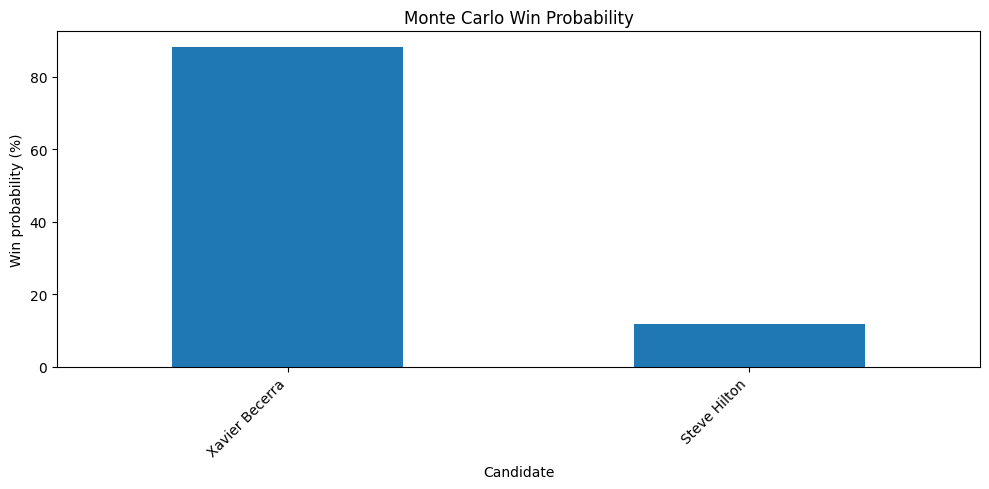

In [7]:
win_probs.plot(
    x="Candidate",
    y="WinProbabilityPercent",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)

plt.ylabel("Win probability (%)")
plt.title("Monte Carlo Win Probability")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
def run_anti_steve_monte_carlo(
    df_counties,
    missing_frac=0.50,
    n_sims=10000,
    seed=42,
    chunk_size=2000,
    blue_shift_low=0.04,
    blue_shift_high=0.08,
    steve_extra_drop_low=0.02,
    steve_extra_drop_high=0.07,
    noise_sd=0.004
):
    arrays = prepare_fast_arrays(df_counties)

    candidates = arrays["candidates"]
    parties = arrays["parties"]
    current_votes = arrays["current_votes"]
    county_totals = arrays["county_totals"]
    base_shares = arrays["base_shares"]

    rng = np.random.default_rng(seed)

    n_counties, n_candidates = base_shares.shape

    dem_mask = parties == DEM
    rep_mask = parties == REP

    steve_idx = np.where(candidates == "Steve Hilton")[0][0]

    becerra_idx = np.where(candidates == "Xavier Becerra")[0][0]
    steyer_idx = np.where(candidates == "Tom Steyer")[0][0]
    porter_idx = np.where(candidates == "Katie Porter")[0][0]
    mahan_idx = np.where(candidates == "Matt Mahan")[0][0]

    dem_total = base_shares[:, dem_mask].sum(axis=1)
    rep_total = base_shares[:, rep_mask].sum(axis=1)

    rep_weights = np.zeros_like(base_shares)
    rep_weights[:, rep_mask] = base_shares[:, rep_mask] / rep_total[:, None]

    # Democratic allocation for the general blue shift
    dem_factors = np.ones(n_candidates)
    dem_factors[becerra_idx] = 1.35
    dem_factors[steyer_idx] = 1.30
    dem_factors[porter_idx] = 1.10
    dem_factors[mahan_idx] = 1.05

    dem_weight_raw = base_shares * dem_mask * dem_factors
    dem_weights = dem_weight_raw / dem_weight_raw.sum(axis=1)[:, None]

    # Where Steve's specific lost votes go
    steve_loss_receivers = np.zeros(n_candidates)
    steve_loss_receivers[becerra_idx] = 0.45
    steve_loss_receivers[steyer_idx] = 0.35
    steve_loss_receivers[porter_idx] = 0.10
    steve_loss_receivers[mahan_idx] = 0.10

    missing_votes = county_totals * missing_frac / (1 - missing_frac)

    all_state_votes = []
    sims_done = 0

    while sims_done < n_sims:
        m = min(chunk_size, n_sims - sims_done)

        shares = np.broadcast_to(
            base_shares[None, :, :],
            (m, n_counties, n_candidates)
        ).copy()

        # Step 1: harsh blue shift
        blue_shift = rng.uniform(
            blue_shift_low,
            blue_shift_high,
            size=(m, n_counties)
        )

        blue_actual = np.minimum(blue_shift, rep_total[None, :])

        shares -= blue_actual[:, :, None] * rep_weights[None, :, :]
        shares += blue_actual[:, :, None] * dem_weights[None, :, :]

        # Step 2: Steve-specific collapse among missing votes
        steve_drop = rng.uniform(
            steve_extra_drop_low,
            steve_extra_drop_high,
            size=(m, n_counties)
        )

        steve_available = shares[:, :, steve_idx]
        actual_steve_drop = np.minimum(steve_drop, steve_available)

        shares[:, :, steve_idx] -= actual_steve_drop

        shares += actual_steve_drop[:, :, None] * steve_loss_receivers[None, None, :]

        # Step 3: small noise
        if noise_sd > 0:
            noise = rng.normal(0, noise_sd, size=shares.shape)
            shares = shares + noise
            shares = np.clip(shares, 0.000001, None)
            shares = shares / shares.sum(axis=2, keepdims=True)

        projected_by_county = (
            current_votes[None, :, :] +
            missing_votes[None, :, None] * shares
        )

        state_votes = projected_by_county.sum(axis=1)
        all_state_votes.append(state_votes)

        sims_done += m

    state_votes_all = np.vstack(all_state_votes)
    state_perc_all = state_votes_all / state_votes_all.sum(axis=1, keepdims=True) * 100

    winner_idx = np.argmax(state_votes_all, axis=1)
    winners = candidates[winner_idx]

    order = np.argsort(-state_votes_all, axis=1)
    top_idx = order[:, 0]
    second_idx = order[:, 1]

    margins_votes = (
        state_votes_all[np.arange(n_sims), top_idx] -
        state_votes_all[np.arange(n_sims), second_idx]
    )

    margins_percent = (
        state_perc_all[np.arange(n_sims), top_idx] -
        state_perc_all[np.arange(n_sims), second_idx]
    )

    sims = pd.DataFrame({
        "sim": np.arange(n_sims),
        "winner": winners,
        "second": candidates[second_idx],
        "margin_votes": margins_votes,
        "margin_percent": margins_percent
    })

    win_probs = (
        sims["winner"]
        .value_counts(normalize=True)
        .mul(100)
        .reset_index()
    )

    win_probs.columns = ["Candidate", "WinProbabilityPercent"]

    rank_matrix = np.empty_like(order)
    rank_matrix[np.arange(n_sims)[:, None], order] = np.arange(1, n_candidates + 1)

    candidate_summary = pd.DataFrame({
        "Name": candidates,
        "Party": parties,
        "AvgProjectedVotes": state_votes_all.mean(axis=0),
        "MedianProjectedVotes": np.median(state_votes_all, axis=0),
        "Low5ProjectedVotes": np.quantile(state_votes_all, 0.05, axis=0),
        "High95ProjectedVotes": np.quantile(state_votes_all, 0.95, axis=0),
        "AvgProjectedPercent": state_perc_all.mean(axis=0),
        "Low5ProjectedPercent": np.quantile(state_perc_all, 0.05, axis=0),
        "High95ProjectedPercent": np.quantile(state_perc_all, 0.95, axis=0),
        "MedianRank": np.median(rank_matrix, axis=0)
    }).sort_values("AvgProjectedVotes", ascending=False).reset_index(drop=True)

    return win_probs, sims, candidate_summary, state_votes_all, state_perc_all

In [9]:
import time

start = time.time()

win_probs_bad, sims_bad, candidate_summary_bad, state_votes_bad, state_perc_bad = run_anti_steve_monte_carlo(
    df_counties,
    missing_frac=0.50,
    n_sims=10000,
    seed=42,
    blue_shift_low=0.04,
    blue_shift_high=0.08,
    steve_extra_drop_low=0.02,
    steve_extra_drop_high=0.07,
    noise_sd=0.004
)

print(f"Finished in {time.time() - start:.2f} seconds")

display(win_probs_bad)
display(candidate_summary_bad.head(10))
display(sims_bad[["margin_votes", "margin_percent"]].describe())

Finished in 0.32 seconds


,Candidate,WinProbabilityPercent
0,Xavier Becerra,100.0


,Name,Party,AvgProjectedVotes,MedianProjectedVotes,Low5ProjectedVotes,High95ProjectedVotes,AvgProjectedPercent,Low5ProjectedPercent,High95ProjectedPercent,MedianRank
0,Xavier Becerra,Dem,3.111665e+06,3.111408e+06,3.081607e+06,3.141563e+06,27.506273,27.240573,27.770565,1.0
1,Steve Hilton,Rep,2.521213e+06,2.521624e+06,2.474018e+06,2.568106e+06,22.286840,21.869645,22.701361,2.0
2,Tom Steyer,Dem,2.407534e+06,2.407376e+06,2.383870e+06,2.431550e+06,21.281952,21.072768,21.494243,3.0
3,Chad Bianco,Rep,1.139732e+06,1.139576e+06,1.126201e+06,1.153363e+06,10.074925,9.955309,10.195415,4.0
4,Katie Porter,Dem,5.413985e+05,5.413904e+05,5.297163e+05,5.531430e+05,4.785816,4.682548,4.889635,5.0
5,Matt Mahan,Dem,4.756494e+05,4.756965e+05,4.641146e+05,4.868567e+05,4.204612,4.102647,4.303681,6.0
6,Antonio Villaraigosa,Dem,1.485278e+05,1.485204e+05,1.377939e+05,1.593077e+05,1.312945,1.218061,1.408237,7.0
7,Tony K. Thurmond,Dem,7.539943e+04,7.535180e+04,6.513239e+04,8.572729e+04,0.666511,0.575753,0.757806,8.0
8,Betty T. Yee,Dem,5.660987e+04,5.634092e+04,4.757960e+04,6.682806e+04,0.500416,0.420591,0.590742,9.0
9,Ramsey Robinson,P&F,4.912293e+04,4.878796e+04,3.989355e+04,5.943834e+04,0.434233,0.352648,0.525419,10.0


,margin_votes,margin_percent
count,10000.000000,10000.000000
mean,590446.603862,5.219388
std,42436.005391,0.375123
min,429169.878756,3.793745
25%,561332.999907,4.962032
50%,590103.408082,5.216354
75%,619768.223553,5.478583
max,728043.540141,6.435708


In [10]:
win_probs_nuke, sims_nuke, candidate_summary_nuke, state_votes_nuke, state_perc_nuke = run_anti_steve_monte_carlo(
    df_counties,
    missing_frac=0.40,
    n_sims=10000,
    seed=42,
    blue_shift_low=0.06,
    blue_shift_high=0.10,
    steve_extra_drop_low=0.04,
    steve_extra_drop_high=0.10,
    noise_sd=0.004
)

display(win_probs_nuke)
display(candidate_summary_nuke.head(10))
display(sims_nuke[["margin_votes", "margin_percent"]].describe())

,Candidate,WinProbabilityPercent
0,Xavier Becerra,100.0


,Name,Party,AvgProjectedVotes,MedianProjectedVotes,Low5ProjectedVotes,High95ProjectedVotes,AvgProjectedPercent,Low5ProjectedPercent,High95ProjectedPercent,MedianRank
0,Xavier Becerra,Dem,2.637503e+06,2.637308e+06,2.615572e+06,2.659387e+06,27.977779,27.745142,28.209917,1.0
1,Steve Hilton,Rep,2.057568e+06,2.057930e+06,2.021841e+06,2.092699e+06,21.826008,21.447028,22.198668,2.0
2,Tom Steyer,Dem,2.040451e+06,2.040262e+06,2.023371e+06,2.057916e+06,21.644443,21.463257,21.829708,3.0
3,Chad Bianco,Rep,9.515962e+05,9.514861e+05,9.425995e+05,9.606644e+05,10.094223,9.998789,10.190416,4.0
4,Katie Porter,Dem,4.596367e+05,4.596395e+05,4.516710e+05,4.676798e+05,4.875676,4.791179,4.960995,5.0
5,Matt Mahan,Dem,4.043386e+05,4.043585e+05,3.964761e+05,4.119995e+05,4.289093,4.205690,4.370357,6.0
6,Antonio Villaraigosa,Dem,1.247098e+05,1.247091e+05,1.175613e+05,1.318940e+05,1.322881,1.247052,1.399088,7.0
7,Tony K. Thurmond,Dem,6.326721e+04,6.324310e+04,5.639727e+04,7.016176e+04,0.671118,0.598244,0.744253,8.0
8,Betty T. Yee,Dem,4.728189e+04,4.710884e+04,4.122698e+04,5.411903e+04,0.501551,0.437322,0.574077,9.0
9,Ramsey Robinson,P&F,4.089209e+04,4.066901e+04,3.473956e+04,4.776752e+04,0.433770,0.368506,0.506702,10.0


,margin_votes,margin_percent
count,10000.000000,10000.000000
mean,574588.857851,6.095052
std,25178.033717,0.267080
min,457579.043693,4.853850
25%,557589.352298,5.914727
50%,579627.627447,6.148501
75%,595309.105121,6.314845
max,625491.153746,6.635007


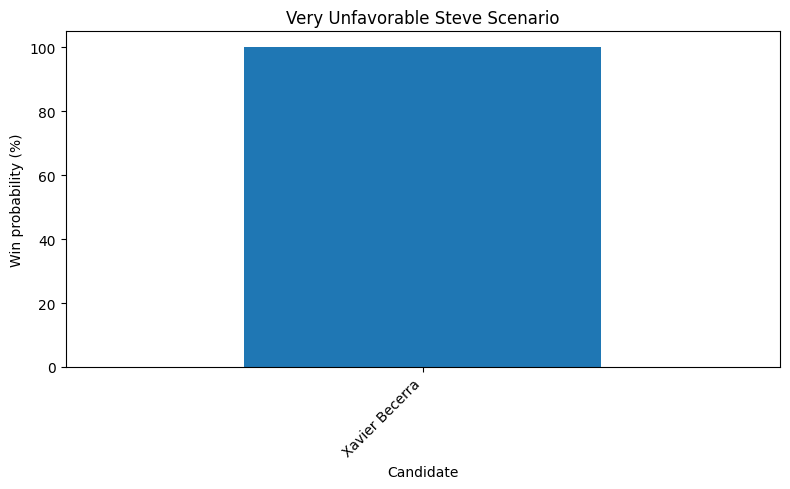

In [11]:
win_probs_bad.plot(
    x="Candidate",
    y="WinProbabilityPercent",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

plt.ylabel("Win probability (%)")
plt.title("Very Unfavorable Steve Scenario")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
def run_realistic_unfavorable_steve_monte_carlo(
    df_counties,
    missing_frac=0.50,
    n_sims=10000,
    seed=42,
    chunk_size=2000,
    blue_shift_mean=0.032,
    blue_shift_sd=0.012,
    blue_shift_low=0.005,
    blue_shift_high=0.060,
    steve_extra_drop_mean=0.008,
    steve_extra_drop_sd=0.006,
    steve_extra_drop_low=0.000,
    steve_extra_drop_high=0.025,
    noise_sd=0.004
):
    """
    Realistic Steve-unfavorable model.

    Current votes stay fixed.

    Missing votes:
    1. Start from current county candidate shares.
    2. Apply a Democratic late-count shift, usually around 3.2 points.
    3. Apply small Steve-specific underperformance, usually below 1 point.
    4. Send Steve's lost share mostly to Becerra and Steyer.
    5. Add small candidate-level noise.
    """

    arrays = prepare_fast_arrays(df_counties)

    candidates = arrays["candidates"]
    parties = arrays["parties"]
    current_votes = arrays["current_votes"]
    county_totals = arrays["county_totals"]
    base_shares = arrays["base_shares"]

    rng = np.random.default_rng(seed)

    n_counties, n_candidates = base_shares.shape

    dem_mask = parties == DEM
    rep_mask = parties == REP

    steve_idx = np.where(candidates == "Steve Hilton")[0][0]
    becerra_idx = np.where(candidates == "Xavier Becerra")[0][0]
    steyer_idx = np.where(candidates == "Tom Steyer")[0][0]

    porter_idx = np.where(candidates == "Katie Porter")[0][0] if "Katie Porter" in candidates else None
    mahan_idx = np.where(candidates == "Matt Mahan")[0][0] if "Matt Mahan" in candidates else None

    dem_total = base_shares[:, dem_mask].sum(axis=1)
    rep_total = base_shares[:, rep_mask].sum(axis=1)

    rep_weights = np.zeros_like(base_shares)
    rep_weights[:, rep_mask] = base_shares[:, rep_mask] / rep_total[:, None]

    # General Democratic gain allocation
    dem_factors = np.ones(n_candidates) * 0.80
    dem_factors[becerra_idx] = 1.35
    dem_factors[steyer_idx] = 1.25

    if porter_idx is not None:
        dem_factors[porter_idx] = 1.05

    if mahan_idx is not None:
        dem_factors[mahan_idx] = 1.00

    dem_weight_raw = base_shares * dem_mask * dem_factors
    dem_weights = dem_weight_raw / dem_weight_raw.sum(axis=1)[:, None]

    # Steve-specific lost votes distribution
    steve_loss_receivers = np.zeros(n_candidates)
    steve_loss_receivers[becerra_idx] = 0.50
    steve_loss_receivers[steyer_idx] = 0.35

    if porter_idx is not None:
        steve_loss_receivers[porter_idx] = 0.075

    if mahan_idx is not None:
        steve_loss_receivers[mahan_idx] = 0.075

    steve_loss_receivers = steve_loss_receivers / steve_loss_receivers.sum()

    missing_votes = county_totals * missing_frac / (1 - missing_frac)

    all_state_votes = []
    sims_done = 0

    while sims_done < n_sims:
        m = min(chunk_size, n_sims - sims_done)

        shares = np.broadcast_to(
            base_shares[None, :, :],
            (m, n_counties, n_candidates)
        ).copy()

        # County-level blue shift
        blue_shift = rng.normal(
            blue_shift_mean,
            blue_shift_sd,
            size=(m, n_counties)
        )

        blue_shift = np.clip(
            blue_shift,
            blue_shift_low,
            blue_shift_high
        )

        blue_actual = np.minimum(blue_shift, rep_total[None, :])

        shares -= blue_actual[:, :, None] * rep_weights[None, :, :]
        shares += blue_actual[:, :, None] * dem_weights[None, :, :]

        # Steve-specific underperformance
        steve_extra_drop = rng.normal(
            steve_extra_drop_mean,
            steve_extra_drop_sd,
            size=(m, n_counties)
        )

        steve_extra_drop = np.clip(
            steve_extra_drop,
            steve_extra_drop_low,
            steve_extra_drop_high
        )

        steve_available = shares[:, :, steve_idx]
        actual_steve_drop = np.minimum(steve_extra_drop, steve_available)

        shares[:, :, steve_idx] -= actual_steve_drop
        shares += actual_steve_drop[:, :, None] * steve_loss_receivers[None, None, :]

        # Small candidate noise
        if noise_sd > 0:
            noise = rng.normal(0, noise_sd, size=shares.shape)
            shares = shares + noise
            shares = np.clip(shares, 0.000001, None)
            shares = shares / shares.sum(axis=2, keepdims=True)

        projected_by_county = (
            current_votes[None, :, :] +
            missing_votes[None, :, None] * shares
        )

        state_votes = projected_by_county.sum(axis=1)
        all_state_votes.append(state_votes)

        sims_done += m

    state_votes_all = np.vstack(all_state_votes)
    state_perc_all = state_votes_all / state_votes_all.sum(axis=1, keepdims=True) * 100

    winner_idx = np.argmax(state_votes_all, axis=1)
    winners = candidates[winner_idx]

    order = np.argsort(-state_votes_all, axis=1)
    top_idx = order[:, 0]
    second_idx = order[:, 1]

    margins_votes = (
        state_votes_all[np.arange(n_sims), top_idx] -
        state_votes_all[np.arange(n_sims), second_idx]
    )

    margins_percent = (
        state_perc_all[np.arange(n_sims), top_idx] -
        state_perc_all[np.arange(n_sims), second_idx]
    )

    sims = pd.DataFrame({
        "sim": np.arange(n_sims),
        "winner": winners,
        "second": candidates[second_idx],
        "margin_votes": margins_votes,
        "margin_percent": margins_percent
    })

    win_probs = (
        sims["winner"]
        .value_counts(normalize=True)
        .mul(100)
        .reset_index()
    )

    win_probs.columns = ["Candidate", "WinProbabilityPercent"]

    rank_matrix = np.empty_like(order)
    rank_matrix[np.arange(n_sims)[:, None], order] = np.arange(1, n_candidates + 1)

    candidate_summary = pd.DataFrame({
        "Name": candidates,
        "Party": parties,
        "AvgProjectedVotes": state_votes_all.mean(axis=0),
        "MedianProjectedVotes": np.median(state_votes_all, axis=0),
        "Low5ProjectedVotes": np.quantile(state_votes_all, 0.05, axis=0),
        "High95ProjectedVotes": np.quantile(state_votes_all, 0.95, axis=0),
        "AvgProjectedPercent": state_perc_all.mean(axis=0),
        "Low5ProjectedPercent": np.quantile(state_perc_all, 0.05, axis=0),
        "High95ProjectedPercent": np.quantile(state_perc_all, 0.95, axis=0),
        "MedianRank": np.median(rank_matrix, axis=0)
    }).sort_values("AvgProjectedVotes", ascending=False).reset_index(drop=True)

    return win_probs, sims, candidate_summary, state_votes_all, state_perc_all

In [13]:
import time

start = time.time()

win_probs_real_bad, sims_real_bad, candidate_summary_real_bad, state_votes_real_bad, state_perc_real_bad = run_realistic_unfavorable_steve_monte_carlo(
    df_counties,
    missing_frac=0.50,
    n_sims=10000,
    seed=42
)

print(f"Finished in {time.time() - start:.2f} seconds")

display(win_probs_real_bad)
display(candidate_summary_real_bad.head(10))
display(sims_real_bad[["margin_votes", "margin_percent"]].describe())

Finished in 0.31 seconds


,Candidate,WinProbabilityPercent
0,Xavier Becerra,100.0


,Name,Party,AvgProjectedVotes,MedianProjectedVotes,Low5ProjectedVotes,High95ProjectedVotes,AvgProjectedPercent,Low5ProjectedPercent,High95ProjectedPercent,MedianRank
0,Xavier Becerra,Dem,2.958536e+06,2.958461e+06,2.933120e+06,2.984668e+06,26.152660,25.927987,26.383659,1.0
1,Steve Hilton,Rep,2.818995e+06,2.818857e+06,2.787268e+06,2.851014e+06,24.919154,24.638691,25.202191,2.0
2,Tom Steyer,Dem,2.286908e+06,2.286857e+06,2.267017e+06,2.306971e+06,20.215645,20.039815,20.393001,3.0
3,Chad Bianco,Rep,1.179258e+06,1.179398e+06,1.165437e+06,1.193024e+06,10.424322,10.302148,10.546007,4.0
4,Katie Porter,Dem,5.106143e+05,5.105962e+05,4.996999e+05,5.217113e+05,4.513692,4.417212,4.611787,5.0
5,Matt Mahan,Dem,4.470175e+05,4.469922e+05,4.360455e+05,4.580600e+05,3.951514,3.854524,4.049126,6.0
6,Antonio Villaraigosa,Dem,1.455085e+05,1.454781e+05,1.346514e+05,1.564115e+05,1.286256,1.190282,1.382635,7.0
7,Tony K. Thurmond,Dem,7.395905e+04,7.385360e+04,6.360497e+04,8.453171e+04,0.653778,0.562251,0.747237,8.0
8,Betty T. Yee,Dem,5.550273e+04,5.522989e+04,4.674016e+04,6.548793e+04,0.490629,0.413170,0.578896,9.0
9,Ramsey Robinson,P&F,4.907242e+04,4.881870e+04,3.975648e+04,5.921644e+04,0.433787,0.351437,0.523457,10.0


,margin_votes,margin_percent
count,10000.000000,10000.000000
mean,139541.154180,1.233506
std,29069.939921,0.256970
min,34826.187232,0.307854
25%,119891.640850,1.059810
50%,139445.182909,1.232658
75%,159108.045867,1.406472
max,254353.834812,2.248419


In [14]:
def sensitivity_grid_realistic_steve(
    df_counties,
    missing_fracs=[0.25, 0.35, 0.50, 0.65],
    blue_shift_means=[0.015, 0.02, 0.025, 0.03, 0.035, 0.04],
    steve_extra_drop_means=[0.000, 0.005, 0.010, 0.015],
    n_sims=3000,
    seed=42
):
    rows = []

    for missing_frac in missing_fracs:
        for blue_mean in blue_shift_means:
            for steve_drop_mean in steve_extra_drop_means:

                win_probs, sims, candidate_summary, _, _ = run_realistic_unfavorable_steve_monte_carlo(
                    df_counties,
                    missing_frac=missing_frac,
                    n_sims=n_sims,
                    seed=seed,
                    blue_shift_mean=blue_mean,
                    blue_shift_sd=0.010,
                    blue_shift_low=0.000,
                    blue_shift_high=0.060,
                    steve_extra_drop_mean=steve_drop_mean,
                    steve_extra_drop_sd=0.005,
                    steve_extra_drop_low=0.000,
                    steve_extra_drop_high=0.025,
                    noise_sd=0.004
                )

                becerra_prob = win_probs.loc[
                    win_probs["Candidate"] == "Xavier Becerra",
                    "WinProbabilityPercent"
                ]

                steve_prob = win_probs.loc[
                    win_probs["Candidate"] == "Steve Hilton",
                    "WinProbabilityPercent"
                ]

                rows.append({
                    "missing_frac": missing_frac,
                    "blue_shift_mean": blue_mean,
                    "steve_extra_drop_mean": steve_drop_mean,
                    "BecerraWinProb": float(becerra_prob.iloc[0]) if len(becerra_prob) else 0.0,
                    "SteveWinProb": float(steve_prob.iloc[0]) if len(steve_prob) else 0.0,
                    "AvgMarginVotes": sims["margin_votes"].mean(),
                    "AvgMarginPercent": sims["margin_percent"].mean()
                })

    return pd.DataFrame(rows)

In [15]:
grid = sensitivity_grid_realistic_steve(
    df_counties,
    n_sims=3000,
    seed=42
)

grid.sort_values("BecerraWinProb", ascending=False).head(20)

,missing_frac,blue_shift_mean,steve_extra_drop_mean,BecerraWinProb,SteveWinProb,AvgMarginVotes,AvgMarginPercent
95,0.65,0.040,0.015,100.0,0.0,507590.851703,3.140876
81,0.65,0.025,0.005,100.0,0.0,192589.378917,1.191707
38,0.35,0.030,0.010,100.0,0.0,45699.849229,0.525167
79,0.65,0.020,0.015,100.0,0.0,276338.759167,1.709932
42,0.35,0.035,0.010,100.0,0.0,62543.448665,0.718727
43,0.35,0.035,0.015,100.0,0.0,83648.387202,0.961258
44,0.35,0.040,0.000,100.0,0.0,44711.217631,0.513806
45,0.35,0.040,0.005,100.0,0.0,59370.413881,0.682264
46,0.35,0.040,0.010,100.0,0.0,79226.368918,0.910442
47,0.35,0.040,0.015,100.0,0.0,100330.838659,1.152967


In [16]:
pivot = grid.pivot_table(
    index="blue_shift_mean",
    columns="steve_extra_drop_mean",
    values="BecerraWinProb"
)

pivot

steve_extra_drop_mean,0.000,0.005,0.010,0.015
blue_shift_mean,,,,
0.015,25.033333,42.075000,59.016667,73.450000
0.020,43.950000,56.000000,70.658333,82.216667
0.025,57.525000,68.841667,79.458333,93.833333
0.030,70.475000,77.516667,91.183333,99.175000
0.035,78.541667,89.341667,98.466667,99.983333
0.040,90.800000,97.883333,99.958333,100.000000


In [17]:
missing_frac=0.50

In [18]:
grid_50 = grid[grid["missing_frac"] == 0.50]

pivot_50 = grid_50.pivot_table(
    index="blue_shift_mean",
    columns="steve_extra_drop_mean",
    values="BecerraWinProb"
)

pivot_50

steve_extra_drop_mean,0.000,0.005,0.010,0.015
blue_shift_mean,,,,
0.015,24.800000,68.200000,97.733333,100.0
0.020,74.133333,95.700000,99.966667,100.0
0.025,97.500000,99.966667,100.000000,100.0
0.030,99.966667,100.000000,100.000000,100.0
0.035,100.000000,100.000000,100.000000,100.0
0.040,100.000000,100.000000,100.000000,100.0


In [19]:
for mf in sorted(grid["missing_frac"].unique()):
    print("\nMissing fraction:", mf)

    pivot_mf = grid[grid["missing_frac"] == mf].pivot_table(
        index="blue_shift_mean",
        columns="steve_extra_drop_mean",
        values="BecerraWinProb"
    )

    display(pivot_mf)


Missing fraction: 0.25


steve_extra_drop_mean,0.000,0.005,0.010,0.015
blue_shift_mean,,,,
0.015,0.000000,0.000000,0.133333,4.066667
0.020,0.000000,0.066667,2.000000,29.700000
0.025,0.066667,0.800000,19.733333,75.333333
0.030,0.966667,13.033333,64.733333,96.700000
0.035,15.833333,57.400000,93.866667,99.933333
0.040,63.200000,91.533333,99.833333,100.000000



Missing fraction: 0.35


steve_extra_drop_mean,0.000,0.005,0.010,0.015
blue_shift_mean,,,,
0.015,0.200000,3.666667,38.200000,89.733333
0.020,4.066667,28.266667,80.666667,99.166667
0.025,32.566667,74.600000,98.100000,100.000000
0.030,80.966667,97.033333,100.000000,100.000000
0.035,98.333333,99.966667,100.000000,100.000000
0.040,100.000000,100.000000,100.000000,100.000000



Missing fraction: 0.5


steve_extra_drop_mean,0.000,0.005,0.010,0.015
blue_shift_mean,,,,
0.015,24.800000,68.200000,97.733333,100.0
0.020,74.133333,95.700000,99.966667,100.0
0.025,97.500000,99.966667,100.000000,100.0
0.030,99.966667,100.000000,100.000000,100.0
0.035,100.000000,100.000000,100.000000,100.0
0.040,100.000000,100.000000,100.000000,100.0



Missing fraction: 0.65


steve_extra_drop_mean,0.000,0.005,0.010,0.015
blue_shift_mean,,,,
0.015,75.133333,96.433333,100.0,100.0
0.020,97.600000,99.966667,100.0,100.0
0.025,99.966667,100.000000,100.0,100.0
0.030,100.000000,100.000000,100.0,100.0
0.035,100.000000,100.000000,100.0,100.0
0.040,100.000000,100.000000,100.0,100.0


In [20]:
grid_realistic = sensitivity_grid_realistic_steve(
    df_counties,
    missing_fracs=[0.35, 0.40, 0.45, 0.50],
    blue_shift_means=[0.020, 0.025, 0.030, 0.035, 0.040],
    steve_extra_drop_means=[0.000, 0.005, 0.010, 0.015],
    n_sims=5000,
    seed=42
)

for mf in sorted(grid_realistic["missing_frac"].unique()):
    print("\nMissing fraction:", mf)

    pivot_mf = grid_realistic[grid_realistic["missing_frac"] == mf].pivot_table(
        index="blue_shift_mean",
        columns="steve_extra_drop_mean",
        values="BecerraWinProb"
    )

    display(pivot_mf)


Missing fraction: 0.35


steve_extra_drop_mean,0.000,0.005,0.010,0.015
blue_shift_mean,,,,
0.020,3.78,27.44,81.42,99.28
0.025,31.82,75.20,98.22,100.00
0.030,80.94,97.30,99.98,100.00
0.035,98.66,99.94,100.00,100.00
0.040,99.98,100.00,100.00,100.00



Missing fraction: 0.4


steve_extra_drop_mean,0.000,0.005,0.010,0.015
blue_shift_mean,,,,
0.020,21.12,64.96,96.66,99.98
0.025,71.02,94.86,99.88,100.00
0.030,97.02,99.84,100.00,100.00
0.035,99.94,100.00,100.00,100.00
0.040,100.00,100.00,100.00,100.00



Missing fraction: 0.45


steve_extra_drop_mean,0.000,0.005,0.010,0.015
blue_shift_mean,,,,
0.020,49.98,86.78,99.54,100.0
0.025,90.84,99.22,100.00,100.0
0.030,99.66,99.98,100.00,100.0
0.035,100.00,100.00,100.00,100.0
0.040,100.00,100.00,100.00,100.0



Missing fraction: 0.5


steve_extra_drop_mean,0.000,0.005,0.010,0.015
blue_shift_mean,,,,
0.020,73.86,95.94,99.94,100.0
0.025,97.68,99.90,100.00,100.0
0.030,99.94,100.00,100.00,100.0
0.035,100.00,100.00,100.00,100.0
0.040,100.00,100.00,100.00,100.0


In [21]:
win_probs_443, sims_443, candidate_summary_443, state_votes_443, state_perc_443 = run_realistic_unfavorable_steve_monte_carlo(
    df_counties,
    missing_frac=0.443,
    n_sims=20000,
    seed=42,
    blue_shift_mean=0.032,
    blue_shift_sd=0.012,
    blue_shift_low=0.005,
    blue_shift_high=0.060,
    steve_extra_drop_mean=0.008,
    steve_extra_drop_sd=0.006,
    steve_extra_drop_low=0.000,
    steve_extra_drop_high=0.025,
    noise_sd=0.004
)

display(win_probs_443)
display(candidate_summary_443.head(10))
display(sims_443[["margin_votes", "margin_percent"]].describe())

,Candidate,WinProbabilityPercent
0,Xavier Becerra,100.0


,Name,Party,AvgProjectedVotes,MedianProjectedVotes,Low5ProjectedVotes,High95ProjectedVotes,AvgProjectedPercent,Low5ProjectedPercent,High95ProjectedPercent,MedianRank
0,Xavier Becerra,Dem,2.654341e+06,2.654249e+06,2.634112e+06,2.675028e+06,26.138510,25.939310,26.342223,1.0
1,Steve Hilton,Rep,2.556798e+06,2.556872e+06,2.531425e+06,2.582118e+06,25.177960,24.928105,25.427301,2.0
2,Tom Steyer,Dem,2.052506e+06,2.052445e+06,2.036595e+06,2.068584e+06,20.211969,20.055284,20.370294,3.0
3,Chad Bianco,Rep,1.067159e+06,1.067260e+06,1.056206e+06,1.078141e+06,10.508807,10.400948,10.616948,4.0
4,Katie Porter,Dem,4.585582e+05,4.585232e+05,4.499061e+05,4.673846e+05,4.515632,4.430432,4.602550,5.0
5,Matt Mahan,Dem,4.014010e+05,4.013819e+05,3.926803e+05,4.101844e+05,3.952779,3.866903,4.039274,6.0
6,Antonio Villaraigosa,Dem,1.307739e+05,1.307472e+05,1.221000e+05,1.393942e+05,1.287790,1.202375,1.372679,7.0
7,Tony K. Thurmond,Dem,6.640144e+04,6.631804e+04,5.818987e+04,7.478007e+04,0.653885,0.573022,0.736394,8.0
8,Betty T. Yee,Dem,4.973265e+04,4.952336e+04,4.266943e+04,5.765617e+04,0.489740,0.420185,0.567767,9.0
9,Ramsey Robinson,P&F,4.400374e+04,4.380907e+04,3.660859e+04,5.212422e+04,0.433325,0.360502,0.513291,10.0


,margin_votes,margin_percent
count,20000.000000,20000.000000
mean,97542.911502,0.960550
std,23025.264363,0.226740
min,13401.458699,0.131970
25%,81869.430605,0.806206
50%,97313.544861,0.958291
75%,113014.800805,1.112909
max,188794.453899,1.859145


In [22]:
grid_443_range = sensitivity_grid_realistic_steve(
    df_counties,
    missing_fracs=[0.40, 0.425, 0.443, 0.46, 0.48],
    blue_shift_means=[0.025, 0.030, 0.032, 0.035, 0.040],
    steve_extra_drop_means=[0.000, 0.005, 0.008, 0.010, 0.015],
    n_sims=5000,
    seed=42
)

for mf in sorted(grid_443_range["missing_frac"].unique()):
    print("\nMissing fraction:", mf)

    pivot_mf = grid_443_range[grid_443_range["missing_frac"] == mf].pivot_table(
        index="blue_shift_mean",
        columns="steve_extra_drop_mean",
        values="BecerraWinProb"
    )

    display(pivot_mf)


Missing fraction: 0.4


steve_extra_drop_mean,0.000,0.005,0.008,0.010,0.015
blue_shift_mean,,,,,
0.025,71.02,94.86,99.34,99.88,100.0
0.030,97.02,99.84,100.00,100.00,100.0
0.032,99.14,99.96,100.00,100.00,100.0
0.035,99.94,100.00,100.00,100.00,100.0
0.040,100.00,100.00,100.00,100.00,100.0



Missing fraction: 0.425


steve_extra_drop_mean,0.000,0.005,0.008,0.010,0.015
blue_shift_mean,,,,,
0.025,83.18,97.80,99.76,99.98,100.0
0.030,98.86,99.94,100.00,100.00,100.0
0.032,99.80,100.00,100.00,100.00,100.0
0.035,99.98,100.00,100.00,100.00,100.0
0.040,100.00,100.00,100.00,100.00,100.0



Missing fraction: 0.443


steve_extra_drop_mean,0.000,0.005,0.008,0.010,0.015
blue_shift_mean,,,,,
0.025,89.30,98.92,99.92,100.0,100.0
0.030,99.50,99.98,100.00,100.0,100.0
0.032,99.92,100.00,100.00,100.0,100.0
0.035,99.98,100.00,100.00,100.0,100.0
0.040,100.00,100.00,100.00,100.0,100.0



Missing fraction: 0.46


steve_extra_drop_mean,0.000,0.005,0.008,0.010,0.015
blue_shift_mean,,,,,
0.025,93.06,99.46,99.96,100.0,100.0
0.030,99.76,100.00,100.00,100.0,100.0
0.032,99.94,100.00,100.00,100.0,100.0
0.035,100.00,100.00,100.00,100.0,100.0
0.040,100.00,100.00,100.00,100.0,100.0



Missing fraction: 0.48


steve_extra_drop_mean,0.000,0.005,0.008,0.010,0.015
blue_shift_mean,,,,,
0.025,95.90,99.72,99.98,100.0,100.0
0.030,99.92,100.00,100.00,100.0,100.0
0.032,99.98,100.00,100.00,100.0,100.0
0.035,100.00,100.00,100.00,100.0,100.0
0.040,100.00,100.00,100.00,100.0,100.0


In [23]:
def run_heavy_anti_steve_top2_monte_carlo(
    df_counties,
    missing_frac=0.443,
    n_sims=50000,
    seed=42,
    chunk_size=5000,
    
    # Strong but still semi-realistic anti-Republican late shift
    blue_shift_mean=0.040,
    blue_shift_sd=0.010,
    blue_shift_low=0.020,
    blue_shift_high=0.065,
    
    # Steve-specific underperformance in the remaining vote
    steve_extra_drop_mean=0.012,
    steve_extra_drop_sd=0.006,
    steve_extra_drop_low=0.000,
    steve_extra_drop_high=0.030,
    
    # Small random candidate noise
    noise_sd=0.004
):
    """
    Realistic but heavily anti-Steve top-two simulation.

    Current votes stay fixed.

    Missing votes:
    - Strong Democratic late-count shift.
    - Steve specifically underperforms.
    - Steyer is helped more than usual, because Steve only misses top two
      if Steyer can catch him.
    """

    arrays = prepare_fast_arrays(df_counties)

    candidates = arrays["candidates"]
    parties = arrays["parties"]
    current_votes = arrays["current_votes"]
    county_totals = arrays["county_totals"]
    base_shares = arrays["base_shares"]

    rng = np.random.default_rng(seed)

    n_counties, n_candidates = base_shares.shape

    dem_mask = parties == DEM
    rep_mask = parties == REP

    steve_idx = np.where(candidates == "Steve Hilton")[0][0]
    becerra_idx = np.where(candidates == "Xavier Becerra")[0][0]
    steyer_idx = np.where(candidates == "Tom Steyer")[0][0]

    porter_idx = np.where(candidates == "Katie Porter")[0][0] if "Katie Porter" in candidates else None
    mahan_idx = np.where(candidates == "Matt Mahan")[0][0] if "Matt Mahan" in candidates else None

    dem_total = base_shares[:, dem_mask].sum(axis=1)
    rep_total = base_shares[:, rep_mask].sum(axis=1)

    # Remove Republican share proportionally
    rep_weights = np.zeros_like(base_shares)
    rep_weights[:, rep_mask] = base_shares[:, rep_mask] / rep_total[:, None]

    # General blue-shift allocation.
    # This favors Becerra and Steyer, with Steyer helped more than usual.
    dem_factors = np.ones(n_candidates) * 0.75
    dem_factors[becerra_idx] = 1.30
    dem_factors[steyer_idx] = 1.55

    if porter_idx is not None:
        dem_factors[porter_idx] = 1.00

    if mahan_idx is not None:
        dem_factors[mahan_idx] = 0.95

    dem_weight_raw = base_shares * dem_mask * dem_factors
    dem_weights = dem_weight_raw / dem_weight_raw.sum(axis=1)[:, None]

    # Steve-specific lost votes.
    # This is intentionally bad for Steve and good for Steyer.
    steve_loss_receivers = np.zeros(n_candidates)
    steve_loss_receivers[becerra_idx] = 0.35
    steve_loss_receivers[steyer_idx] = 0.50

    if porter_idx is not None:
        steve_loss_receivers[porter_idx] = 0.075

    if mahan_idx is not None:
        steve_loss_receivers[mahan_idx] = 0.075

    steve_loss_receivers = steve_loss_receivers / steve_loss_receivers.sum()

    missing_votes = county_totals * missing_frac / (1 - missing_frac)

    all_state_votes = []
    sims_done = 0

    while sims_done < n_sims:
        m = min(chunk_size, n_sims - sims_done)

        shares = np.broadcast_to(
            base_shares[None, :, :],
            (m, n_counties, n_candidates)
        ).copy()

        # Strong county-level blue shift
        blue_shift = rng.normal(
            blue_shift_mean,
            blue_shift_sd,
            size=(m, n_counties)
        )

        blue_shift = np.clip(
            blue_shift,
            blue_shift_low,
            blue_shift_high
        )

        blue_actual = np.minimum(blue_shift, rep_total[None, :])

        shares -= blue_actual[:, :, None] * rep_weights[None, :, :]
        shares += blue_actual[:, :, None] * dem_weights[None, :, :]

        # Steve-specific underperformance
        steve_extra_drop = rng.normal(
            steve_extra_drop_mean,
            steve_extra_drop_sd,
            size=(m, n_counties)
        )

        steve_extra_drop = np.clip(
            steve_extra_drop,
            steve_extra_drop_low,
            steve_extra_drop_high
        )

        steve_available = shares[:, :, steve_idx]
        actual_steve_drop = np.minimum(steve_extra_drop, steve_available)

        shares[:, :, steve_idx] -= actual_steve_drop
        shares += actual_steve_drop[:, :, None] * steve_loss_receivers[None, None, :]

        # Random candidate noise
        if noise_sd > 0:
            noise = rng.normal(0, noise_sd, size=shares.shape)
            shares = shares + noise
            shares = np.clip(shares, 0.000001, None)
            shares = shares / shares.sum(axis=2, keepdims=True)

        projected_by_county = (
            current_votes[None, :, :] +
            missing_votes[None, :, None] * shares
        )

        state_votes = projected_by_county.sum(axis=1)
        all_state_votes.append(state_votes)

        sims_done += m

    state_votes_all = np.vstack(all_state_votes)
    state_perc_all = state_votes_all / state_votes_all.sum(axis=1, keepdims=True) * 100

    order = np.argsort(-state_votes_all, axis=1)

    rank_matrix = np.empty_like(order)
    rank_matrix[np.arange(n_sims)[:, None], order] = np.arange(1, n_candidates + 1)

    steve_rank = rank_matrix[:, steve_idx]
    steve_makes_top2 = steve_rank <= 2

    top1 = candidates[order[:, 0]]
    top2 = candidates[order[:, 1]]
    top3 = candidates[order[:, 2]]

    sims = pd.DataFrame({
        "sim": np.arange(n_sims),
        "top1": top1,
        "top2": top2,
        "top3": top3,
        "steve_rank": steve_rank,
        "steve_makes_top2": steve_makes_top2
    })

    steve_summary = pd.DataFrame({
        "Metric": [
            "Steve top-two probability",
            "Steve misses top-two probability",
            "Steve average rank",
            "Steve median rank"
        ],
        "Value": [
            steve_makes_top2.mean() * 100,
            (1 - steve_makes_top2.mean()) * 100,
            steve_rank.mean(),
            np.median(steve_rank)
        ]
    })

    candidate_summary = pd.DataFrame({
        "Name": candidates,
        "Party": parties,
        "AvgProjectedVotes": state_votes_all.mean(axis=0),
        "MedianProjectedVotes": np.median(state_votes_all, axis=0),
        "Low5ProjectedVotes": np.quantile(state_votes_all, 0.05, axis=0),
        "High95ProjectedVotes": np.quantile(state_votes_all, 0.95, axis=0),
        "AvgProjectedPercent": state_perc_all.mean(axis=0),
        "Low5ProjectedPercent": np.quantile(state_perc_all, 0.05, axis=0),
        "High95ProjectedPercent": np.quantile(state_perc_all, 0.95, axis=0),
        "TopTwoProbability": (rank_matrix <= 2).mean(axis=0) * 100,
        "MedianRank": np.median(rank_matrix, axis=0)
    }).sort_values("AvgProjectedVotes", ascending=False).reset_index(drop=True)

    top_two_matchups = (
        sims
        .groupby(["top1", "top2"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    top_two_matchups["probability_percent"] = top_two_matchups["count"] / n_sims * 100

    return steve_summary, candidate_summary, sims, top_two_matchups, state_votes_all, state_perc_all

In [24]:
import time

start = time.time()

steve_summary_heavy, candidate_summary_heavy, sims_heavy, matchups_heavy, state_votes_heavy, state_perc_heavy = run_heavy_anti_steve_top2_monte_carlo(
    df_counties,
    missing_frac=0.443,
    n_sims=50000,
    seed=42
)

print(f"Finished in {time.time() - start:.2f} seconds")

display(steve_summary_heavy)
display(candidate_summary_heavy.head(10))
display(matchups_heavy.head(10))

Finished in 1.62 seconds


,Metric,Value
0,Steve top-two probability,100.0
1,Steve misses top-two probability,0.0
2,Steve average rank,2.0
3,Steve median rank,2.0


,Name,Party,AvgProjectedVotes,MedianProjectedVotes,Low5ProjectedVotes,High95ProjectedVotes,AvgProjectedPercent,Low5ProjectedPercent,High95ProjectedPercent,TopTwoProbability,MedianRank
0,Xavier Becerra,Dem,2.663872e+06,2.663813e+06,2.645881e+06,2.682236e+06,26.232369,26.055205,26.413207,100.0,1.0
1,Steve Hilton,Rep,2.517075e+06,2.517030e+06,2.493946e+06,2.540135e+06,24.786789,24.559026,25.013875,100.0,2.0
2,Tom Steyer,Dem,2.087573e+06,2.087455e+06,2.071096e+06,2.104360e+06,20.557285,20.395035,20.722594,0.0,3.0
3,Chad Bianco,Rep,1.058124e+06,1.058113e+06,1.047643e+06,1.068569e+06,10.419827,10.316618,10.522687,0.0,4.0
4,Katie Porter,Dem,4.608686e+05,4.608803e+05,4.522116e+05,4.694855e+05,4.538384,4.453134,4.623239,0.0,5.0
5,Matt Mahan,Dem,4.035295e+05,4.035336e+05,3.947935e+05,4.122368e+05,3.973740,3.887712,4.059485,0.0,6.0
6,Antonio Villaraigosa,Dem,1.309959e+05,1.309666e+05,1.225470e+05,1.395322e+05,1.289977,1.206776,1.374037,0.0,7.0
7,Tony K. Thurmond,Dem,6.652013e+04,6.646483e+04,5.832427e+04,7.481277e+04,0.655054,0.574346,0.736716,0.0,8.0
8,Betty T. Yee,Dem,4.988482e+04,4.964019e+04,4.277010e+04,5.787188e+04,0.491239,0.421177,0.569891,0.0,9.0
9,Ramsey Robinson,P&F,4.398680e+04,4.379491e+04,3.661005e+04,5.197033e+04,0.433158,0.360516,0.511776,0.0,10.0


,top1,top2,count,probability_percent
0,Xavier Becerra,Steve Hilton,50000,100.0


In [25]:
sims_heavy["steve_rank"].value_counts(normalize=True).sort_index() * 100

steve_rank
2    100.0
Name: proportion, dtype: float64

In [26]:
misses = sims_heavy[sims_heavy["steve_makes_top2"] == False]

misses[["top1", "top2", "top3"]].value_counts(normalize=True).mul(100).head(10)

Series([], Name: proportion, dtype: float64)

In [27]:
def run_steyer_surge_anti_steve_top2_monte_carlo(
    df_counties,
    missing_frac=0.443,
    n_sims=50000,
    seed=42,
    chunk_size=5000,

    # Anti-Steve / pro-Dem late vote
    blue_shift_mean=0.038,
    blue_shift_sd=0.010,
    blue_shift_low=0.015,
    blue_shift_high=0.065,

    # Steve personally underperforms late ballots
    steve_extra_drop_mean=0.012,
    steve_extra_drop_sd=0.006,
    steve_extra_drop_low=0.000,
    steve_extra_drop_high=0.030,

    # Small random candidate noise
    noise_sd=0.004
):
    arrays = prepare_fast_arrays(df_counties)

    candidates = arrays["candidates"]
    parties = arrays["parties"]
    current_votes = arrays["current_votes"]
    county_totals = arrays["county_totals"]
    base_shares = arrays["base_shares"]

    rng = np.random.default_rng(seed)

    n_counties, n_candidates = base_shares.shape

    dem_mask = parties == DEM
    rep_mask = parties == REP

    steve_idx = np.where(candidates == "Steve Hilton")[0][0]
    becerra_idx = np.where(candidates == "Xavier Becerra")[0][0]
    steyer_idx = np.where(candidates == "Tom Steyer")[0][0]

    porter_idx = np.where(candidates == "Katie Porter")[0][0] if "Katie Porter" in candidates else None
    mahan_idx = np.where(candidates == "Matt Mahan")[0][0] if "Matt Mahan" in candidates else None

    dem_total = base_shares[:, dem_mask].sum(axis=1)
    rep_total = base_shares[:, rep_mask].sum(axis=1)

    # Republicans lose share proportionally
    rep_weights = np.zeros_like(base_shares)
    rep_weights[:, rep_mask] = base_shares[:, rep_mask] / rep_total[:, None]

    # General Democratic late-vote gain allocation.
    # This is intentionally very favorable to Tom Steyer.
    dem_factors = np.ones(n_candidates) * 0.70
    dem_factors[becerra_idx] = 1.15
    dem_factors[steyer_idx] = 2.20

    if porter_idx is not None:
        dem_factors[porter_idx] = 0.90

    if mahan_idx is not None:
        dem_factors[mahan_idx] = 0.85

    dem_weight_raw = base_shares * dem_mask * dem_factors
    dem_weights = dem_weight_raw / dem_weight_raw.sum(axis=1)[:, None]

    # Steve-specific lost votes.
    # Most of Steve's extra lost share goes to Steyer.
    steve_loss_receivers = np.zeros(n_candidates)
    steve_loss_receivers[steyer_idx] = 0.70
    steve_loss_receivers[becerra_idx] = 0.20

    if porter_idx is not None:
        steve_loss_receivers[porter_idx] = 0.05

    if mahan_idx is not None:
        steve_loss_receivers[mahan_idx] = 0.05

    steve_loss_receivers = steve_loss_receivers / steve_loss_receivers.sum()

    missing_votes = county_totals * missing_frac / (1 - missing_frac)

    all_state_votes = []
    sims_done = 0

    while sims_done < n_sims:
        m = min(chunk_size, n_sims - sims_done)

        shares = np.broadcast_to(
            base_shares[None, :, :],
            (m, n_counties, n_candidates)
        ).copy()

        # Strong Democratic late-count shift
        blue_shift = rng.normal(
            blue_shift_mean,
            blue_shift_sd,
            size=(m, n_counties)
        )

        blue_shift = np.clip(
            blue_shift,
            blue_shift_low,
            blue_shift_high
        )

        blue_actual = np.minimum(blue_shift, rep_total[None, :])

        shares -= blue_actual[:, :, None] * rep_weights[None, :, :]
        shares += blue_actual[:, :, None] * dem_weights[None, :, :]

        # Steve-specific underperformance
        steve_extra_drop = rng.normal(
            steve_extra_drop_mean,
            steve_extra_drop_sd,
            size=(m, n_counties)
        )

        steve_extra_drop = np.clip(
            steve_extra_drop,
            steve_extra_drop_low,
            steve_extra_drop_high
        )

        steve_available = shares[:, :, steve_idx]
        actual_steve_drop = np.minimum(steve_extra_drop, steve_available)

        shares[:, :, steve_idx] -= actual_steve_drop
        shares += actual_steve_drop[:, :, None] * steve_loss_receivers[None, None, :]

        # Candidate-level noise
        if noise_sd > 0:
            noise = rng.normal(0, noise_sd, size=shares.shape)
            shares = shares + noise
            shares = np.clip(shares, 0.000001, None)
            shares = shares / shares.sum(axis=2, keepdims=True)

        projected_by_county = (
            current_votes[None, :, :] +
            missing_votes[None, :, None] * shares
        )

        state_votes = projected_by_county.sum(axis=1)
        all_state_votes.append(state_votes)

        sims_done += m

    state_votes_all = np.vstack(all_state_votes)
    state_perc_all = state_votes_all / state_votes_all.sum(axis=1, keepdims=True) * 100

    order = np.argsort(-state_votes_all, axis=1)

    rank_matrix = np.empty_like(order)
    rank_matrix[np.arange(n_sims)[:, None], order] = np.arange(1, n_candidates + 1)

    steve_rank = rank_matrix[:, steve_idx]
    steyer_rank = rank_matrix[:, steyer_idx]
    becerra_rank = rank_matrix[:, becerra_idx]

    steve_makes_top2 = steve_rank <= 2
    steyer_makes_top2 = steyer_rank <= 2
    becerra_makes_top2 = becerra_rank <= 2

    top1 = candidates[order[:, 0]]
    top2 = candidates[order[:, 1]]
    top3 = candidates[order[:, 2]]

    sims = pd.DataFrame({
        "sim": np.arange(n_sims),
        "top1": top1,
        "top2": top2,
        "top3": top3,
        "steve_rank": steve_rank,
        "steyer_rank": steyer_rank,
        "becerra_rank": becerra_rank,
        "steve_makes_top2": steve_makes_top2,
        "steyer_makes_top2": steyer_makes_top2,
        "becerra_makes_top2": becerra_makes_top2
    })

    candidate_summary = pd.DataFrame({
        "Name": candidates,
        "Party": parties,
        "AvgProjectedVotes": state_votes_all.mean(axis=0),
        "MedianProjectedVotes": np.median(state_votes_all, axis=0),
        "Low5ProjectedVotes": np.quantile(state_votes_all, 0.05, axis=0),
        "High95ProjectedVotes": np.quantile(state_votes_all, 0.95, axis=0),
        "AvgProjectedPercent": state_perc_all.mean(axis=0),
        "Low5ProjectedPercent": np.quantile(state_perc_all, 0.05, axis=0),
        "High95ProjectedPercent": np.quantile(state_perc_all, 0.95, axis=0),
        "TopTwoProbability": (rank_matrix <= 2).mean(axis=0) * 100,
        "MedianRank": np.median(rank_matrix, axis=0)
    }).sort_values("AvgProjectedVotes", ascending=False).reset_index(drop=True)

    top_two_matchups = (
        sims
        .groupby(["top1", "top2"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    top_two_matchups["probability_percent"] = top_two_matchups["count"] / n_sims * 100

    steve_summary = pd.DataFrame({
        "Metric": [
            "Steve top-two probability",
            "Steve misses top-two probability",
            "Steve average rank",
            "Steve median rank",
            "Steyer top-two probability",
            "Becerra top-two probability"
        ],
        "Value": [
            steve_makes_top2.mean() * 100,
            (1 - steve_makes_top2.mean()) * 100,
            steve_rank.mean(),
            np.median(steve_rank),
            steyer_makes_top2.mean() * 100,
            becerra_makes_top2.mean() * 100
        ]
    })

    return steve_summary, candidate_summary, sims, top_two_matchups, state_votes_all, state_perc_all

In [28]:
import time

start = time.time()

steve_summary_steyer, candidate_summary_steyer, sims_steyer, matchups_steyer, state_votes_steyer, state_perc_steyer = run_steyer_surge_anti_steve_top2_monte_carlo(
    df_counties,
    missing_frac=0.443,
    n_sims=50000,
    seed=42
)

print(f"Finished in {time.time() - start:.2f} seconds")

display(steve_summary_steyer)
display(candidate_summary_steyer.head(10))
display(matchups_steyer.head(10))

Finished in 1.55 seconds


,Metric,Value
0,Steve top-two probability,100.0
1,Steve misses top-two probability,0.0
2,Steve average rank,2.0
3,Steve median rank,2.0
4,Steyer top-two probability,0.0
5,Becerra top-two probability,100.0


,Name,Party,AvgProjectedVotes,MedianProjectedVotes,Low5ProjectedVotes,High95ProjectedVotes,AvgProjectedPercent,Low5ProjectedPercent,High95ProjectedPercent,TopTwoProbability,MedianRank
0,Xavier Becerra,Dem,2.638173e+06,2.638147e+06,2.621546e+06,2.655108e+06,25.979299,25.815566,26.146061,100.0,1.0
1,Steve Hilton,Rep,2.523036e+06,2.522987e+06,2.499787e+06,2.546252e+06,24.845494,24.616545,25.074109,100.0,2.0
2,Tom Steyer,Dem,2.112675e+06,2.112565e+06,2.093622e+06,2.132063e+06,20.804478,20.616855,20.995398,0.0,3.0
3,Chad Bianco,Rep,1.060400e+06,1.060391e+06,1.049881e+06,1.070882e+06,10.442243,10.338662,10.545469,0.0,4.0
4,Katie Porter,Dem,4.573217e+05,4.573238e+05,4.487183e+05,4.658727e+05,4.503456,4.418735,4.587662,0.0,5.0
5,Matt Mahan,Dem,4.003718e+05,4.003837e+05,3.916790e+05,4.090147e+05,3.942644,3.857043,4.027755,0.0,6.0
6,Antonio Villaraigosa,Dem,1.305773e+05,1.305517e+05,1.221356e+05,1.391086e+05,1.285855,1.202725,1.369866,0.0,7.0
7,Tony K. Thurmond,Dem,6.631036e+04,6.625644e+04,5.812485e+04,7.458863e+04,0.652988,0.572382,0.734508,0.0,8.0
8,Betty T. Yee,Dem,4.974102e+04,4.949317e+04,4.264542e+04,5.772510e+04,0.489823,0.419949,0.568445,0.0,9.0
9,Ramsey Robinson,P&F,4.398637e+04,4.379438e+04,3.660978e+04,5.196954e+04,0.433154,0.360513,0.511768,0.0,10.0


,top1,top2,count,probability_percent
0,Xavier Becerra,Steve Hilton,50000,100.0


In [29]:
sims_steyer["steve_rank"].value_counts(normalize=True).sort_index() * 100

steve_rank
2    100.0
Name: proportion, dtype: float64

In [30]:
steve_misses = sims_steyer[sims_steyer["steve_makes_top2"] == False]

steve_misses[["top1", "top2", "top3"]].value_counts(normalize=True).mul(100).head(10)

Series([], Name: proportion, dtype: float64)

In [31]:
def run_tom_swing_vs_steve(
    df_counties,
    missing_frac=0.443,
    tom_extra_swing=0.00,
    n_sims=20000,
    seed=42,
    chunk_size=5000,

    # Background anti-Steve / blue-shift assumptions
    blue_shift_mean=0.038,
    blue_shift_sd=0.010,
    blue_shift_low=0.015,
    blue_shift_high=0.065,

    steve_extra_drop_mean=0.012,
    steve_extra_drop_sd=0.006,
    steve_extra_drop_low=0.000,
    steve_extra_drop_high=0.030,

    noise_sd=0.004
):
    """
    tom_extra_swing = extra share of missing votes transferred directly
    from Steve Hilton to Tom Steyer in each county.

    Example:
    tom_extra_swing=0.05 means Tom gets +5 percentage points of the
    remaining vote in each county, taken from Steve.
    """

    arrays = prepare_fast_arrays(df_counties)

    candidates = arrays["candidates"]
    parties = arrays["parties"]
    current_votes = arrays["current_votes"]
    county_totals = arrays["county_totals"]
    base_shares = arrays["base_shares"]

    rng = np.random.default_rng(seed)

    n_counties, n_candidates = base_shares.shape

    dem_mask = parties == DEM
    rep_mask = parties == REP

    steve_idx = np.where(candidates == "Steve Hilton")[0][0]
    tom_idx = np.where(candidates == "Tom Steyer")[0][0]
    becerra_idx = np.where(candidates == "Xavier Becerra")[0][0]

    porter_idx = np.where(candidates == "Katie Porter")[0][0] if "Katie Porter" in candidates else None
    mahan_idx = np.where(candidates == "Matt Mahan")[0][0] if "Matt Mahan" in candidates else None

    dem_total = base_shares[:, dem_mask].sum(axis=1)
    rep_total = base_shares[:, rep_mask].sum(axis=1)

    rep_weights = np.zeros_like(base_shares)
    rep_weights[:, rep_mask] = base_shares[:, rep_mask] / rep_total[:, None]

    # Blue-shift allocation, favorable to Tom
    dem_factors = np.ones(n_candidates) * 0.70
    dem_factors[becerra_idx] = 1.15
    dem_factors[tom_idx] = 2.20

    if porter_idx is not None:
        dem_factors[porter_idx] = 0.90

    if mahan_idx is not None:
        dem_factors[mahan_idx] = 0.85

    dem_weight_raw = base_shares * dem_mask * dem_factors
    dem_weights = dem_weight_raw / dem_weight_raw.sum(axis=1)[:, None]

    # Steve-specific loss mostly to Tom
    steve_loss_receivers = np.zeros(n_candidates)
    steve_loss_receivers[tom_idx] = 0.70
    steve_loss_receivers[becerra_idx] = 0.20

    if porter_idx is not None:
        steve_loss_receivers[porter_idx] = 0.05

    if mahan_idx is not None:
        steve_loss_receivers[mahan_idx] = 0.05

    steve_loss_receivers = steve_loss_receivers / steve_loss_receivers.sum()

    missing_votes = county_totals * missing_frac / (1 - missing_frac)

    all_state_votes = []
    sims_done = 0

    while sims_done < n_sims:
        m = min(chunk_size, n_sims - sims_done)

        shares = np.broadcast_to(
            base_shares[None, :, :],
            (m, n_counties, n_candidates)
        ).copy()

        # General blue shift
        blue_shift = rng.normal(
            blue_shift_mean,
            blue_shift_sd,
            size=(m, n_counties)
        )

        blue_shift = np.clip(
            blue_shift,
            blue_shift_low,
            blue_shift_high
        )

        blue_actual = np.minimum(blue_shift, rep_total[None, :])

        shares -= blue_actual[:, :, None] * rep_weights[None, :, :]
        shares += blue_actual[:, :, None] * dem_weights[None, :, :]

        # Steve-specific underperformance
        steve_extra_drop = rng.normal(
            steve_extra_drop_mean,
            steve_extra_drop_sd,
            size=(m, n_counties)
        )

        steve_extra_drop = np.clip(
            steve_extra_drop,
            steve_extra_drop_low,
            steve_extra_drop_high
        )

        actual_steve_drop = np.minimum(steve_extra_drop, shares[:, :, steve_idx])

        shares[:, :, steve_idx] -= actual_steve_drop
        shares += actual_steve_drop[:, :, None] * steve_loss_receivers[None, None, :]

        # The key experiment:
        # extra missing-vote share transferred from Steve directly to Tom
        actual_tom_swing = np.minimum(tom_extra_swing, shares[:, :, steve_idx])

        shares[:, :, steve_idx] -= actual_tom_swing
        shares[:, :, tom_idx] += actual_tom_swing

        # Small candidate noise
        if noise_sd > 0:
            noise = rng.normal(0, noise_sd, size=shares.shape)
            shares = shares + noise
            shares = np.clip(shares, 0.000001, None)
            shares = shares / shares.sum(axis=2, keepdims=True)

        projected_by_county = (
            current_votes[None, :, :] +
            missing_votes[None, :, None] * shares
        )

        state_votes = projected_by_county.sum(axis=1)
        all_state_votes.append(state_votes)

        sims_done += m

    state_votes_all = np.vstack(all_state_votes)
    state_perc_all = state_votes_all / state_votes_all.sum(axis=1, keepdims=True) * 100

    steve_votes = state_votes_all[:, steve_idx]
    tom_votes = state_votes_all[:, tom_idx]

    tom_beats_steve = tom_votes > steve_votes

    result = {
        "tom_extra_swing": tom_extra_swing,
        "tom_extra_swing_percent_points": tom_extra_swing * 100,
        "TomBeatsSteveProbability": tom_beats_steve.mean() * 100,
        "AvgTomVotes": tom_votes.mean(),
        "AvgSteveVotes": steve_votes.mean(),
        "AvgTomMinusSteveVotes": (tom_votes - steve_votes).mean(),
        "MedianTomMinusSteveVotes": np.median(tom_votes - steve_votes),
        "Low5TomMinusSteveVotes": np.quantile(tom_votes - steve_votes, 0.05),
        "High95TomMinusSteveVotes": np.quantile(tom_votes - steve_votes, 0.95),
    }

    return result

In [32]:
def tom_swing_grid(
    df_counties,
    swings=np.arange(0.00, 0.151, 0.005),
    missing_frac=0.443,
    n_sims=20000,
    seed=42
):
    rows = []

    for swing in swings:
        print(f"Running Tom swing = {swing*100:.1f} percentage points")

        result = run_tom_swing_vs_steve(
            df_counties,
            missing_frac=missing_frac,
            tom_extra_swing=swing,
            n_sims=n_sims,
            seed=seed
        )

        rows.append(result)

    return pd.DataFrame(rows)

In [33]:
tom_grid = tom_swing_grid(
    df_counties,
    swings=np.arange(0.00, 0.151, 0.005),
    missing_frac=0.4,
    n_sims=20000,
    seed=42
)

tom_grid

Running Tom swing = 0.0 percentage points
Running Tom swing = 0.5 percentage points
Running Tom swing = 1.0 percentage points
Running Tom swing = 1.5 percentage points
Running Tom swing = 2.0 percentage points
Running Tom swing = 2.5 percentage points
Running Tom swing = 3.0 percentage points
Running Tom swing = 3.5 percentage points
Running Tom swing = 4.0 percentage points
Running Tom swing = 4.5 percentage points
Running Tom swing = 5.0 percentage points
Running Tom swing = 5.5 percentage points
Running Tom swing = 6.0 percentage points
Running Tom swing = 6.5 percentage points
Running Tom swing = 7.0 percentage points
Running Tom swing = 7.5 percentage points
Running Tom swing = 8.0 percentage points
Running Tom swing = 8.5 percentage points
Running Tom swing = 9.0 percentage points
Running Tom swing = 9.5 percentage points
Running Tom swing = 10.0 percentage points
Running Tom swing = 10.5 percentage points
Running Tom swing = 11.0 percentage points
Running Tom swing = 11.5 percen

,tom_extra_swing,tom_extra_swing_percent_points,TomBeatsSteveProbability,AvgTomVotes,AvgSteveVotes,AvgTomMinusSteveVotes,MedianTomMinusSteveVotes,Low5TomMinusSteveVotes,High95TomMinusSteveVotes
0,0.000,0.0,0.000,1.955552e+06,2.363583e+06,-408030.821552,-408150.619122,-438406.473965,-376827.830342
1,0.005,0.5,0.000,1.973247e+06,2.345887e+06,-372640.391977,-372754.341525,-402977.332278,-341386.738804
2,0.010,1.0,0.000,1.990942e+06,2.328192e+06,-337249.962401,-337363.958929,-367579.560061,-305947.057400
3,0.015,1.5,0.000,2.008637e+06,2.310497e+06,-301859.532826,-302017.206821,-332107.891144,-270628.222351
4,0.020,2.0,0.000,2.026333e+06,2.292802e+06,-266469.103250,-266628.512781,-296771.727558,-235200.927322
5,0.025,2.5,0.000,2.044028e+06,2.275106e+06,-231078.673675,-231236.848216,-261401.095474,-199750.256833
6,0.030,3.0,0.000,2.061723e+06,2.257411e+06,-195688.244099,-195877.932878,-226111.951032,-164314.642499
7,0.035,3.5,0.000,2.079418e+06,2.239716e+06,-160297.870597,-160474.513965,-190707.008608,-128846.583150
8,0.040,4.0,0.000,2.097113e+06,2.222021e+06,-124907.731229,-125067.227831,-155402.548831,-93430.940910
9,0.045,4.5,0.000,2.114808e+06,2.204327e+06,-89519.355583,-89671.595329,-120040.084799,-58050.701088


In [34]:
threshold_50 = tom_grid[tom_grid["TomBeatsSteveProbability"] >= 50].head(1)
threshold_90 = tom_grid[tom_grid["TomBeatsSteveProbability"] >= 90].head(1)

display(threshold_50)
display(threshold_90)

,tom_extra_swing,tom_extra_swing_percent_points,TomBeatsSteveProbability,AvgTomVotes,AvgSteveVotes,AvgTomMinusSteveVotes,MedianTomMinusSteveVotes,Low5TomMinusSteveVotes,High95TomMinusSteveVotes
12,0.06,6.0,80.625,2.167841e+06,2.151307e+06,16533.209363,16373.889653,-14240.855781,48171.283248


,tom_extra_swing,tom_extra_swing_percent_points,TomBeatsSteveProbability,AvgTomVotes,AvgSteveVotes,AvgTomMinusSteveVotes,MedianTomMinusSteveVotes,Low5TomMinusSteveVotes,High95TomMinusSteveVotes
13,0.065,6.5,99.75,2.185456e+06,2.133704e+06,51752.120874,51524.553241,20978.134612,83402.844689


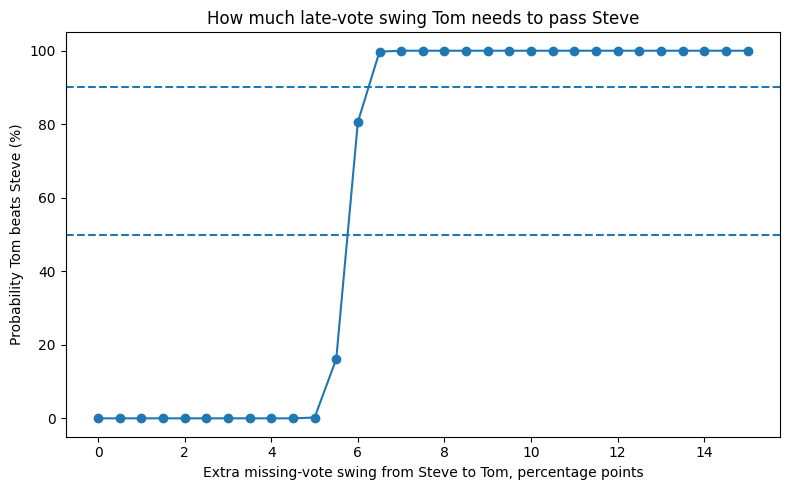

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    tom_grid["tom_extra_swing_percent_points"],
    tom_grid["TomBeatsSteveProbability"],
    marker="o"
)

plt.axhline(50, linestyle="--")
plt.axhline(90, linestyle="--")

plt.xlabel("Extra missing-vote swing from Steve to Tom, percentage points")
plt.ylabel("Probability Tom beats Steve (%)")
plt.title("How much late-vote swing Tom needs to pass Steve")
plt.tight_layout()
plt.show()

In [36]:
import numpy as np
import pandas as pd
import time

STEVE = "Steve Hilton"
BECERRA = "Xavier Becerra"
TOM = "Tom Steyer"
PORTER = "Katie Porter"
MAHAN = "Matt Mahan"
DEM = "Dem"
REP = "Rep"


def run_tom_band_scenario(
    df_counties,
    scenario_name,
    missing_frac=0.443,
    n_sims=50000,
    seed=42,
    chunk_size=5000,
    blue_shift_mean=0.032,
    blue_shift_sd=0.010,
    blue_shift_low=0.005,
    blue_shift_high=0.060,
    steve_extra_drop_mean=0.008,
    steve_extra_drop_sd=0.006,
    steve_extra_drop_low=0.000,
    steve_extra_drop_high=0.025,
    tom_factor=1.15,
    becerra_factor=1.25,
    porter_factor=1.00,
    mahan_factor=0.95,
    other_dem_factor=0.80,
    steve_loss_to_tom=0.35,
    steve_loss_to_becerra=0.50,
    tom_tilt_mean=0.000,
    tom_tilt_sd=0.004,
    tom_tilt_low=-0.010,
    tom_tilt_high=0.015,
    noise_sd=0.003
):
    """
    Vectorized Monte Carlo.

    tom_tilt:
        positive = Tom gains missing-vote share from other Democrats
        negative = Tom loses missing-vote share to other Democrats

    All swings are applied only to the uncounted/missing votes.
    Counted votes stay fixed.
    """

    arrays = prepare_fast_arrays(df_counties)

    candidates = arrays["candidates"]
    parties = arrays["parties"]
    current_votes = arrays["current_votes"]
    county_totals = arrays["county_totals"]
    base_shares = arrays["base_shares"]

    rng = np.random.default_rng(seed)

    n_counties, n_candidates = base_shares.shape

    dem_mask = parties == DEM
    rep_mask = parties == REP

    steve_idx = np.where(candidates == STEVE)[0][0]
    becerra_idx = np.where(candidates == BECERRA)[0][0]
    tom_idx = np.where(candidates == TOM)[0][0]

    porter_idx = np.where(candidates == PORTER)[0][0] if PORTER in candidates else None
    mahan_idx = np.where(candidates == MAHAN)[0][0] if MAHAN in candidates else None

    dem_total = base_shares[:, dem_mask].sum(axis=1)
    rep_total = base_shares[:, rep_mask].sum(axis=1)

    rep_weights = np.zeros_like(base_shares)
    rep_weights[:, rep_mask] = base_shares[:, rep_mask] / rep_total[:, None]

    # Democratic allocation of the general blue shift
    dem_factors = np.ones(n_candidates) * other_dem_factor
    dem_factors[becerra_idx] = becerra_factor
    dem_factors[tom_idx] = tom_factor

    if porter_idx is not None:
        dem_factors[porter_idx] = porter_factor

    if mahan_idx is not None:
        dem_factors[mahan_idx] = mahan_factor

    dem_weight_raw = base_shares * dem_mask * dem_factors
    dem_weights = dem_weight_raw / dem_weight_raw.sum(axis=1)[:, None]

    # Steve-specific lost votes distribution
    steve_loss_receivers = np.zeros(n_candidates)
    steve_loss_receivers[tom_idx] = steve_loss_to_tom
    steve_loss_receivers[becerra_idx] = steve_loss_to_becerra

    remaining = 1 - steve_loss_receivers.sum()

    extra_dems = []
    if porter_idx is not None:
        extra_dems.append(porter_idx)
    if mahan_idx is not None:
        extra_dems.append(mahan_idx)

    if extra_dems and remaining > 0:
        for idx in extra_dems:
            steve_loss_receivers[idx] = remaining / len(extra_dems)

    steve_loss_receivers = steve_loss_receivers / steve_loss_receivers.sum()

    missing_votes = county_totals * missing_frac / (1 - missing_frac)

    all_state_votes = []
    sims_done = 0

    while sims_done < n_sims:
        m = min(chunk_size, n_sims - sims_done)

        shares = np.broadcast_to(
            base_shares[None, :, :],
            (m, n_counties, n_candidates)
        ).copy()

        # 1. General California-style blue shift
        blue_shift = rng.normal(
            blue_shift_mean,
            blue_shift_sd,
            size=(m, n_counties)
        )

        blue_shift = np.clip(
            blue_shift,
            blue_shift_low,
            blue_shift_high
        )

        blue_actual = np.minimum(blue_shift, rep_total[None, :])

        shares -= blue_actual[:, :, None] * rep_weights[None, :, :]
        shares += blue_actual[:, :, None] * dem_weights[None, :, :]

        # 2. Steve-specific late underperformance
        steve_extra_drop = rng.normal(
            steve_extra_drop_mean,
            steve_extra_drop_sd,
            size=(m, n_counties)
        )

        steve_extra_drop = np.clip(
            steve_extra_drop,
            steve_extra_drop_low,
            steve_extra_drop_high
        )

        actual_steve_drop = np.minimum(
            steve_extra_drop,
            shares[:, :, steve_idx]
        )

        shares[:, :, steve_idx] -= actual_steve_drop
        shares += actual_steve_drop[:, :, None] * steve_loss_receivers[None, None, :]

        # 3. Tom-specific tilt within Democratic candidates
        # Positive tilt helps Tom. Negative tilt hurts Tom.
        tom_tilt = rng.normal(
            tom_tilt_mean,
            tom_tilt_sd,
            size=(m, n_counties)
        )

        tom_tilt = np.clip(tom_tilt, tom_tilt_low, tom_tilt_high)

        other_dem_mask = dem_mask.copy()
        other_dem_mask[tom_idx] = False

        positive_tilt = np.maximum(tom_tilt, 0)
        negative_tilt = np.maximum(-tom_tilt, 0)

        # Tom gains from other Dems
        other_dem_total = shares[:, :, other_dem_mask].sum(axis=2)
        actual_positive = np.minimum(positive_tilt, other_dem_total)

        other_dem_weights = shares[:, :, other_dem_mask] / other_dem_total[:, :, None]
        shares[:, :, other_dem_mask] -= actual_positive[:, :, None] * other_dem_weights
        shares[:, :, tom_idx] += actual_positive

        # Tom loses to other Dems
        actual_negative = np.minimum(negative_tilt, shares[:, :, tom_idx])
        shares[:, :, tom_idx] -= actual_negative

        other_dem_total_after = shares[:, :, other_dem_mask].sum(axis=2)
        other_dem_weights_after = shares[:, :, other_dem_mask] / other_dem_total_after[:, :, None]
        shares[:, :, other_dem_mask] += actual_negative[:, :, None] * other_dem_weights_after

        # 4. Small candidate noise
        if noise_sd > 0:
            noise = rng.normal(0, noise_sd, size=shares.shape)
            shares = shares + noise
            shares = np.clip(shares, 0.000001, None)
            shares = shares / shares.sum(axis=2, keepdims=True)

        projected_by_county = (
            current_votes[None, :, :] +
            missing_votes[None, :, None] * shares
        )

        state_votes = projected_by_county.sum(axis=1)
        all_state_votes.append(state_votes)

        sims_done += m

    state_votes_all = np.vstack(all_state_votes)
    state_perc_all = state_votes_all / state_votes_all.sum(axis=1, keepdims=True) * 100

    order = np.argsort(-state_votes_all, axis=1)

    rank_matrix = np.empty_like(order)
    rank_matrix[np.arange(n_sims)[:, None], order] = np.arange(1, n_candidates + 1)

    tom_pct = state_perc_all[:, tom_idx]
    tom_rank = rank_matrix[:, tom_idx]

    tom_summary = {
        "scenario": scenario_name,
        "missing_frac": missing_frac,
        "TomBetween16And20Prob": ((tom_pct >= 16) & (tom_pct <= 20)).mean() * 100,
        "TomBelow16Prob": (tom_pct < 16).mean() * 100,
        "TomAbove20Prob": (tom_pct > 20).mean() * 100,
        "TomTopTwoProb": (tom_rank <= 2).mean() * 100,
        "TomAvgPercent": tom_pct.mean(),
        "TomMedianPercent": np.median(tom_pct),
        "TomLow5Percent": np.quantile(tom_pct, 0.05),
        "TomHigh95Percent": np.quantile(tom_pct, 0.95),
        "TomAvgRank": tom_rank.mean(),
        "TomMedianRank": np.median(tom_rank)
    }

    candidate_summary = pd.DataFrame({
        "scenario": scenario_name,
        "Name": candidates,
        "Party": parties,
        "AvgProjectedVotes": state_votes_all.mean(axis=0),
        "MedianProjectedVotes": np.median(state_votes_all, axis=0),
        "Low5ProjectedVotes": np.quantile(state_votes_all, 0.05, axis=0),
        "High95ProjectedVotes": np.quantile(state_votes_all, 0.95, axis=0),
        "AvgProjectedPercent": state_perc_all.mean(axis=0),
        "MedianProjectedPercent": np.median(state_perc_all, axis=0),
        "Low5ProjectedPercent": np.quantile(state_perc_all, 0.05, axis=0),
        "High95ProjectedPercent": np.quantile(state_perc_all, 0.95, axis=0),
        "TopTwoProbability": (rank_matrix <= 2).mean(axis=0) * 100,
        "MedianRank": np.median(rank_matrix, axis=0)
    }).sort_values(["scenario", "AvgProjectedVotes"], ascending=[True, False]).reset_index(drop=True)

    return tom_summary, candidate_summary, state_votes_all, state_perc_all

In [37]:
def run_tom_band_suite(
    df_counties,
    missing_frac=0.443,
    n_sims=50000,
    seed=42
):
    scenarios = [
        {
            "scenario_name": "Tom unfavorable realistic",
            "blue_shift_mean": 0.028,
            "blue_shift_sd": 0.010,
            "blue_shift_low": 0.000,
            "blue_shift_high": 0.055,
            "steve_extra_drop_mean": 0.006,
            "steve_extra_drop_sd": 0.005,
            "steve_extra_drop_low": 0.000,
            "steve_extra_drop_high": 0.020,
            "tom_factor": 0.70,
            "becerra_factor": 1.45,
            "porter_factor": 1.05,
            "mahan_factor": 1.00,
            "other_dem_factor": 0.80,
            "steve_loss_to_tom": 0.15,
            "steve_loss_to_becerra": 0.70,
            "tom_tilt_mean": -0.004,
            "tom_tilt_sd": 0.004,
            "tom_tilt_low": -0.015,
            "tom_tilt_high": 0.006,
            "noise_sd": 0.003
        },
        {
            "scenario_name": "Neutral realistic",
            "blue_shift_mean": 0.032,
            "blue_shift_sd": 0.010,
            "blue_shift_low": 0.005,
            "blue_shift_high": 0.060,
            "steve_extra_drop_mean": 0.008,
            "steve_extra_drop_sd": 0.006,
            "steve_extra_drop_low": 0.000,
            "steve_extra_drop_high": 0.025,
            "tom_factor": 1.15,
            "becerra_factor": 1.25,
            "porter_factor": 1.00,
            "mahan_factor": 0.95,
            "other_dem_factor": 0.80,
            "steve_loss_to_tom": 0.35,
            "steve_loss_to_becerra": 0.50,
            "tom_tilt_mean": 0.000,
            "tom_tilt_sd": 0.004,
            "tom_tilt_low": -0.010,
            "tom_tilt_high": 0.010,
            "noise_sd": 0.003
        },
        {
            "scenario_name": "Tom favorable realistic",
            "blue_shift_mean": 0.036,
            "blue_shift_sd": 0.010,
            "blue_shift_low": 0.010,
            "blue_shift_high": 0.065,
            "steve_extra_drop_mean": 0.010,
            "steve_extra_drop_sd": 0.006,
            "steve_extra_drop_low": 0.000,
            "steve_extra_drop_high": 0.030,
            "tom_factor": 1.70,
            "becerra_factor": 1.15,
            "porter_factor": 0.95,
            "mahan_factor": 0.90,
            "other_dem_factor": 0.75,
            "steve_loss_to_tom": 0.55,
            "steve_loss_to_becerra": 0.30,
            "tom_tilt_mean": 0.006,
            "tom_tilt_sd": 0.004,
            "tom_tilt_low": -0.004,
            "tom_tilt_high": 0.018,
            "noise_sd": 0.003
        },
        {
            "scenario_name": "Tom high-end realistic",
            "blue_shift_mean": 0.040,
            "blue_shift_sd": 0.010,
            "blue_shift_low": 0.015,
            "blue_shift_high": 0.070,
            "steve_extra_drop_mean": 0.012,
            "steve_extra_drop_sd": 0.006,
            "steve_extra_drop_low": 0.000,
            "steve_extra_drop_high": 0.030,
            "tom_factor": 2.10,
            "becerra_factor": 1.05,
            "porter_factor": 0.90,
            "mahan_factor": 0.85,
            "other_dem_factor": 0.70,
            "steve_loss_to_tom": 0.70,
            "steve_loss_to_becerra": 0.20,
            "tom_tilt_mean": 0.010,
            "tom_tilt_sd": 0.004,
            "tom_tilt_low": 0.000,
            "tom_tilt_high": 0.025,
            "noise_sd": 0.003
        }
    ]

    tom_rows = []
    candidate_summaries = []

    for cfg in scenarios:
        print("Running:", cfg["scenario_name"])

        tom_summary, candidate_summary, _, _ = run_tom_band_scenario(
            df_counties,
            missing_frac=missing_frac,
            n_sims=n_sims,
            seed=seed,
            **cfg
        )

        tom_rows.append(tom_summary)
        candidate_summaries.append(candidate_summary)

    tom_summary_all = pd.DataFrame(tom_rows)
    candidate_summary_all = pd.concat(candidate_summaries, ignore_index=True)

    return tom_summary_all, candidate_summary_all

In [38]:
start = time.time()

tom_summary_all, candidate_summary_all = run_tom_band_suite(
    df_counties,
    missing_frac=0.443,
    n_sims=50000,
    seed=42
)

print(f"Finished in {time.time() - start:.2f} seconds")

display(tom_summary_all)

Running: Tom unfavorable realistic
Running: Neutral realistic
Running: Tom favorable realistic
Running: Tom high-end realistic
Finished in 13.67 seconds


,scenario,missing_frac,TomBetween16And20Prob,TomBelow16Prob,TomAbove20Prob,TomTopTwoProb,TomAvgPercent,TomMedianPercent,TomLow5Percent,TomHigh95Percent,TomAvgRank,TomMedianRank
0,Tom unfavorable realistic,0.443,83.24,0.0,16.76,0.0,19.920380,19.920599,19.783903,20.056662,3.0,3.0
1,Neutral realistic,0.443,0.00,0.0,100.00,0.0,20.375770,20.375879,20.220474,20.530326,3.0,3.0
2,Tom favorable realistic,0.443,0.00,0.0,100.00,0.0,20.969973,20.970345,20.791171,21.149122,3.0,3.0
3,Tom high-end realistic,0.443,0.00,0.0,100.00,0.0,21.460819,21.461110,21.262850,21.659046,3.0,3.0


In [39]:
top_candidates_by_scenario = (
    candidate_summary_all
    .sort_values(["scenario", "AvgProjectedVotes"], ascending=[True, False])
    .groupby("scenario")
    .head(6)
)

display(
    top_candidates_by_scenario[
        [
            "scenario",
            "Name",
            "Party",
            "AvgProjectedVotes",
            "AvgProjectedPercent",
            "Low5ProjectedPercent",
            "High95ProjectedPercent",
            "TopTwoProbability",
            "MedianRank"
        ]
    ]
)

,scenario,Name,Party,AvgProjectedVotes,AvgProjectedPercent,Low5ProjectedPercent,High95ProjectedPercent,TopTwoProbability,MedianRank
61,Neutral realistic,Xavier Becerra,Dem,2.676244e+06,26.354205,26.176669,26.533778,100.0,1.0
62,Neutral realistic,Steve Hilton,Rep,2.576048e+06,25.367527,25.149294,25.583945,100.0,2.0
63,Neutral realistic,Tom Steyer,Dem,2.069140e+06,20.375770,20.220474,20.530326,0.0,3.0
64,Neutral realistic,Chad Bianco,Rep,1.075465e+06,10.590595,10.503996,10.677646,0.0,4.0
65,Neutral realistic,Katie Porter,Dem,4.626712e+05,4.556136,4.489446,4.623322,0.0,5.0
66,Neutral realistic,Matt Mahan,Dem,4.049185e+05,3.987418,3.920505,4.054286,0.0,6.0
122,Tom favorable realistic,Xavier Becerra,Dem,2.649110e+06,26.087004,25.927604,26.248574,100.0,1.0
123,Tom favorable realistic,Steve Hilton,Rep,2.555907e+06,25.169183,24.949141,25.389032,100.0,2.0
124,Tom favorable realistic,Tom Steyer,Dem,2.129481e+06,20.969973,20.791171,21.149122,0.0,3.0
125,Tom favorable realistic,Chad Bianco,Rep,1.070831e+06,10.544962,10.458493,10.631786,0.0,4.0


In [40]:
tom_summary_all[
    [
        "scenario",
        "TomBetween16And20Prob",
        "TomBelow16Prob",
        "TomAbove20Prob",
        "TomTopTwoProb",
        "TomAvgPercent",
        "TomLow5Percent",
        "TomHigh95Percent",
        "TomMedianRank"
    ]
]

,scenario,TomBetween16And20Prob,TomBelow16Prob,TomAbove20Prob,TomTopTwoProb,TomAvgPercent,TomLow5Percent,TomHigh95Percent,TomMedianRank
0,Tom unfavorable realistic,83.24,0.0,16.76,0.0,19.920380,19.783903,20.056662,3.0
1,Neutral realistic,0.00,0.0,100.00,0.0,20.375770,20.220474,20.530326,3.0
2,Tom favorable realistic,0.00,0.0,100.00,0.0,20.969973,20.791171,21.149122,3.0
3,Tom high-end realistic,0.00,0.0,100.00,0.0,21.460819,21.262850,21.659046,3.0
